In [1]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


2min Segment

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# Load dataset
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'
data = pd.read_csv(file_path)

# Drop non-feature columns
X = data.drop(columns=[ "Sl. No:", "Segment_Number", "File_Name", "label"])
y = data["label"].map({"before_HI": 0, "during_HI": 1})  # Encode labels as 0 and 1


# Split classes
group1 = X[y == 0]   # before_HI
group2 = X[y == 1]   # during_HI

results = []

for feature in X.columns:
    x1 = group1[feature].dropna()
    x2 = group2[feature].dropna()

    # Mann–Whitney U Test (Two-tailed)
    stat, p_value = mannwhitneyu(x1, x2, alternative='two-sided')

    results.append([feature, p_value])

# Create DataFrame with ALL p-values
pval_df = pd.DataFrame(results, columns=["Feature", "P_Value"])

# Save all p-values
all_pval_path = "/content/drive/MyDrive/Features_CS6/2minMannWhitney_All_PValues.csv"
pval_df.to_csv(all_pval_path, index=False)

# Extract significant features (p < 0.05)
significant_df = pval_df[pval_df["P_Value"] < 0.05].sort_values("P_Value")

# Save significant p-values separately
significant_path = "/content/drive/MyDrive/Features_CS6/MannWhitney_2min_Significant_PValues.csv"
significant_df.to_csv(significant_path, index=False)

# Display results
print("✅ All Mann–Whitney p-values saved at:")
print(all_pval_path)

print("\n✅ Significant Features (p < 0.05):")
print(significant_df)

print("\n✅ Number of significant features:", len(significant_df))

print("\n📁 Saved at:")
print(significant_path)


✅ All Mann–Whitney p-values saved at:
/content/drive/MyDrive/Features_CS6/2minMannWhitney_All_PValues.csv

✅ Significant Features (p < 0.05):
                              Feature       P_Value
11                 approximateEntropy  1.790279e-13
12                      sampleEntropy  5.095333e-12
5                            variance  4.859179e-08
34                       fd_bandPower  7.270187e-08
4                   standardDeviation  2.652548e-07
16                       renyiEntropy  4.008242e-07
29               fd_standardDeviation  1.338959e-05
30                        fd_variance  1.361703e-05
17                lempelZivComplexity  1.507082e-05
14  singularValueDecompositionEntropy  5.992030e-05
20                         fisherInfo  9.760816e-05
18                     hjorthMobility  1.425579e-04
10                  meanAbsoluteValue  1.649692e-04
23                          higuchiFd  5.020051e-04
1                             minimum  3.786618e-03
8                numberOfZ

Feature Contribution

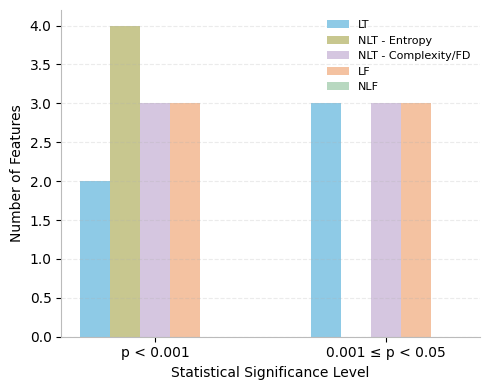

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ----- Data -----
categories = ['p < 0.001', '0.001 ≤ p < 0.05']

# Order:
# [Linear Time, NLT-Entropy, NLT-Complexity/FD,
#  Linear Frequency, Nonlinear Frequency]

p_less_001 = [2, 4, 3, 3, 0]
p_between  = [3, 0, 3, 3, 0]

x = np.arange(len(categories))
width = 0.13

fig, ax = plt.subplots(figsize=(5,4))

# ----- Colors -----
colors = [
    '#8ecae6',   # Linear Time (original teal)
    '#c8c78f',   # NLT - Entropy (original olive)
    '#d5c6e0',   # NLT - Complexity/FD (lavender pastel)
    '#f4c2a1',   # Linear Frequency (peach pastel)
    '#b8d8c0'    # Nonlinear Frequency (sage pastel)
]

labels = [
    'LT',
    'NLT - Entropy',
    'NLT - Complexity/FD',
    'LF',
    'NLF'
]

data = np.array([p_less_001, p_between]).T

# ----- Plot -----
for i in range(5):
    ax.bar(x + (i-2)*width,
           data[i],
           width,
           color=colors[i],
           edgecolor='none',
           label=labels[i])

# ----- Styling -----
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Number of Features')
ax.set_xlabel('Statistical Significance Level')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_color('#bbbbbb')
ax.spines['bottom'].set_color('#bbbbbb')

ax.grid(axis='y', linestyle='--', alpha=0.25)

ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()


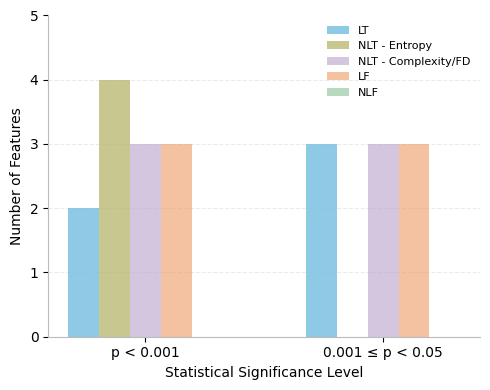

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ----- Data -----
categories = ['p < 0.001', '0.001 ≤ p < 0.05']

# Order:
# [Linear Time, NLT-Entropy, NLT-Complexity/FD,
#  Linear Frequency, Nonlinear Frequency]

p_less_001 = [2, 4, 3, 3, 0]
p_between  = [3, 0, 3, 3, 0]

x = np.arange(len(categories))
width = 0.13

fig, ax = plt.subplots(figsize=(5,4))

# ----- Colors -----
colors = [
    '#8ecae6',   # LT (original teal)
    '#c8c78f',   # NLT - Entropy (original olive)
    '#d5c6e0',   # NLT - Complexity/FD
    '#f4c2a1',   # LF
    '#b8d8c0'    # NLF
]

labels = [
    'LT',
    'NLT - Entropy',
    'NLT - Complexity/FD',
    'LF',
    'NLF'
]

data = np.array([p_less_001, p_between]).T

# ----- Plot -----
for i in range(5):
    ax.bar(x + (i-2)*width,
           data[i],
           width,
           color=colors[i],
           edgecolor='none',
           label=labels[i])

# ----- Styling -----
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Number of Features')
ax.set_xlabel('Statistical Significance Level')

# Integer y-axis only
max_value = np.max(data)
ax.set_ylim(0, max_value + 1)
ax.set_yticks(np.arange(0, max_value + 2, 1))

# Remove top/right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Thin light axes
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_color('#bbbbbb')
ax.spines['bottom'].set_color('#bbbbbb')

# Light horizontal grid
ax.grid(axis='y', linestyle='--', alpha=0.25)

ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()


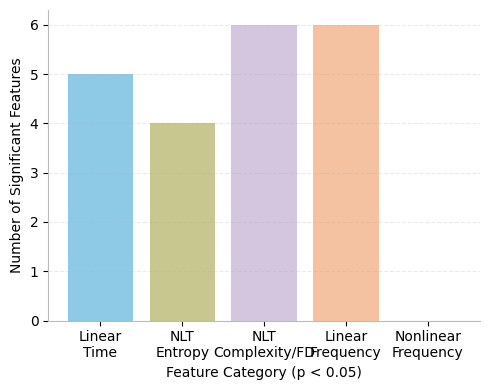

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ----- Data (All p < 0.05) -----
categories = [
    'Linear\nTime',
    'NLT\nEntropy',
    'NLT\nComplexity/FD',
    'Linear\nFrequency',
    'Nonlinear\nFrequency'
]

values = [5, 4, 6, 6, 0]

x = np.arange(len(categories))

fig, ax = plt.subplots(figsize=(5,4))

# ----- Colors (retain original + 3 soft pastels) -----
colors = [
    '#8ecae6',   # Linear Time (original teal)
    '#c8c78f',   # NLT - Entropy (original olive)
    '#d5c6e0',   # NLT - Complexity/FD
    '#f4c2a1',   # Linear Frequency
    '#b8d8c0'    # Nonlinear Frequency
]

bars = ax.bar(x, values, color=colors, edgecolor='none')

# ----- Styling -----
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Number of Significant Features')
ax.set_xlabel('Feature Category (p < 0.05)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_color('#bbbbbb')
ax.spines['bottom'].set_color('#bbbbbb')

ax.grid(axis='y', linestyle='--', alpha=0.25)

plt.tight_layout()
plt.show()


PCA + 5fold CV

In [ ]:
# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'
data = pd.read_csv(file_path)

X = data.drop(columns=["Sl. No:", "Segment_Number", "File_Name", "label"])
y = data["label"].map({"before_HI": 0, "during_HI": 1})


# ======================================================
# ✅ USE ALL 21 SIGNIFICANT FEATURES
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "variance",
    "fd_bandPower",
    "standardDeviation",
    "renyiEntropy",
    "fd_standardDeviation",
    "fd_variance",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "fisherInfo",
    "hjorthMobility",
    "meanAbsoluteValue",
    "higuchiFd",
    "minimum",
    "numberOfZeroCrossing",
    "fd_mean",
    "fd_median",
    "petrosianFd",
    "fd_maximum",
    "katzFd"
]

X_final = X[sig_features]


# ======================================================
# ✅ MODELS
# ======================================================
models = {
    "RF (Raw)": RandomForestClassifier(n_estimators=100, random_state=3),
    "SVM (Raw)": SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=3),
    "LR (Raw)": LogisticRegression(C=1.0, solver='liblinear', penalty='l2', random_state=3),
    "LDA (Raw)": LDA(),

    "RF (PCA)": RandomForestClassifier(n_estimators=100, random_state=3),
    "SVM (PCA)": SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=3),
    "LR (PCA)": LogisticRegression(C=1.0, solver='liblinear', penalty='l2', random_state=3),
    "LDA (PCA)": LDA()
}


# ======================================================
# ✅ STRATIFIED 5-FOLD CV
# ======================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=3)

results = {name: [] for name in models.keys()}


# ======================================================
# ✅ CROSS-VALIDATION LOOP
# ======================================================
for train_idx, test_idx in skf.split(X_final, y):

    X_train = X_final.iloc[train_idx]
    X_test = X_final.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # --------------------------------------------------
    # SCALE (needed before PCA and linear models)
    # --------------------------------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --------------------------------------------------
    # PCA (retain 95% variance)
    # --------------------------------------------------
    pca = PCA(n_components=0.95)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # ==================================================
    # RAW MODELS
    # ==================================================
    models["RF (Raw)"].fit(X_train, y_train)
    probs = models["RF (Raw)"].predict_proba(X_test)[:, 1]
    results["RF (Raw)"].append(roc_auc_score(y_test, probs))

    models["SVM (Raw)"].fit(X_train_scaled, y_train)
    probs = models["SVM (Raw)"].predict_proba(X_test_scaled)[:, 1]
    results["SVM (Raw)"].append(roc_auc_score(y_test, probs))

    models["LR (Raw)"].fit(X_train_scaled, y_train)
    probs = models["LR (Raw)"].predict_proba(X_test_scaled)[:, 1]
    results["LR (Raw)"].append(roc_auc_score(y_test, probs))

    models["LDA (Raw)"].fit(X_train_scaled, y_train)
    probs = models["LDA (Raw)"].predict_proba(X_test_scaled)[:, 1]
    results["LDA (Raw)"].append(roc_auc_score(y_test, probs))

    # ==================================================
    # PCA MODELS
    # ==================================================
    models["RF (PCA)"].fit(X_train_pca, y_train)
    probs = models["RF (PCA)"].predict_proba(X_test_pca)[:, 1]
    results["RF (PCA)"].append(roc_auc_score(y_test, probs))

    models["SVM (PCA)"].fit(X_train_pca, y_train)
    probs = models["SVM (PCA)"].predict_proba(X_test_pca)[:, 1]
    results["SVM (PCA)"].append(roc_auc_score(y_test, probs))

    models["LR (PCA)"].fit(X_train_pca, y_train)
    probs = models["LR (PCA)"].predict_proba(X_test_pca)[:, 1]
    results["LR (PCA)"].append(roc_auc_score(y_test, probs))

    models["LDA (PCA)"].fit(X_train_pca, y_train)
    probs = models["LDA (PCA)"].predict_proba(X_test_pca)[:, 1]
    results["LDA (PCA)"].append(roc_auc_score(y_test, probs))


# ======================================================
# ✅ PRINT RESULTS
# ======================================================
print("\n====================================")
print("RAW vs PCA (95% Variance)")
print("====================================")

for name, scores in results.items():
    print(f"{name}: {np.mean(scores):.4f}")



RAW vs PCA (95% Variance)
RF (Raw): 0.9780
SVM (Raw): 0.8616
LR (Raw): 0.8306
LDA (Raw): 0.8399
RF (PCA): 0.9452
SVM (PCA): 0.8128
LR (PCA): 0.7169
LDA (PCA): 0.7070


Redundancy check

In [ ]:
import numpy as np
import pandas as pd

# Use only the significant features from Mann–Whitney
sig_features = significant_df["Feature"].tolist()
X_sig = X[sig_features]

# Compute absolute correlation matrix
corr = X_sig.corr().abs()

# Extract upper triangle only
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

redundant_pairs = []

threshold = 0.90  # redundancy threshold

for row in upper.index:
    for col in upper.columns:
        val = upper.loc[row, col]
        if pd.notna(val) and val > threshold:
            redundant_pairs.append((row, col, val))

# ✅ FINAL OUTPUT LOGIC
if len(redundant_pairs) == 0:
    print("✅ No redundant feature pairs found (|r| > 0.90).")
    print("✅ All statistically significant features are retained.")

else:
    print("\n⚠️ Redundant feature pairs detected (|r| > 0.90):\n")

    features_to_remove = []

    for f1, f2, r in redundant_pairs:
        print(f"{f1}  ↔  {f2}   (r = {r:.3f})")

        # ✅ Automatic suggestion rule:
        # Keep entropy/complexity, remove simple statistical duplicates
        if "variance" in f1.lower() or "std" in f1.lower() or "minimum" in f1.lower():
            remove = f1
        else:
            remove = f2

        features_to_remove.append(remove)
        print(f"➡️ Suggested removal: {remove}\n")

    final_features = [f for f in sig_features if f not in set(features_to_remove)]

    print("✅ Final non-redundant feature set:")
    for f in final_features:
        print("-", f)

    print("\n✅ Number of retained features:", len(final_features))



⚠️ Redundant feature pairs detected (|r| > 0.90):

variance  ↔  fd_bandPower   (r = 1.000)
➡️ Suggested removal: variance

variance  ↔  standardDeviation   (r = 0.991)
➡️ Suggested removal: variance

variance  ↔  fd_standardDeviation   (r = 0.994)
➡️ Suggested removal: variance

variance  ↔  fd_variance   (r = 0.998)
➡️ Suggested removal: variance

variance  ↔  meanAbsoluteValue   (r = 0.993)
➡️ Suggested removal: variance

variance  ↔  fd_maximum   (r = 0.937)
➡️ Suggested removal: variance

fd_bandPower  ↔  standardDeviation   (r = 0.991)
➡️ Suggested removal: standardDeviation

fd_bandPower  ↔  fd_standardDeviation   (r = 0.994)
➡️ Suggested removal: fd_standardDeviation

fd_bandPower  ↔  fd_variance   (r = 0.998)
➡️ Suggested removal: fd_variance

fd_bandPower  ↔  meanAbsoluteValue   (r = 0.993)
➡️ Suggested removal: meanAbsoluteValue

fd_bandPower  ↔  fd_maximum   (r = 0.937)
➡️ Suggested removal: fd_maximum

standardDeviation  ↔  fd_standardDeviation   (r = 0.996)
➡️ Suggested r

ML


Random Forest — 5-Fold Cross-Validation
Fold 1 AUC: 0.9899
Fold 2 AUC: 0.9638
Fold 3 AUC: 0.9832
Fold 4 AUC: 0.9423
Fold 5 AUC: 0.9885

Mean AUC ± SD: 0.9735 ± 0.0182

SVM (RBF) — 5-Fold Cross-Validation
Fold 1 AUC: 0.9010
Fold 2 AUC: 0.8987
Fold 3 AUC: 0.8837
Fold 4 AUC: 0.8048
Fold 5 AUC: 0.8741

Mean AUC ± SD: 0.8725 ± 0.0353

Logistic Regression — 5-Fold Cross-Validation
Fold 1 AUC: 0.8547
Fold 2 AUC: 0.7598
Fold 3 AUC: 0.8646
Fold 4 AUC: 0.7333
Fold 5 AUC: 0.7902

Mean AUC ± SD: 0.8005 ± 0.0516

LDA — 5-Fold Cross-Validation
Fold 1 AUC: 0.8605
Fold 2 AUC: 0.7656
Fold 3 AUC: 0.8756
Fold 4 AUC: 0.7202
Fold 5 AUC: 0.7665

Mean AUC ± SD: 0.7977 ± 0.0600


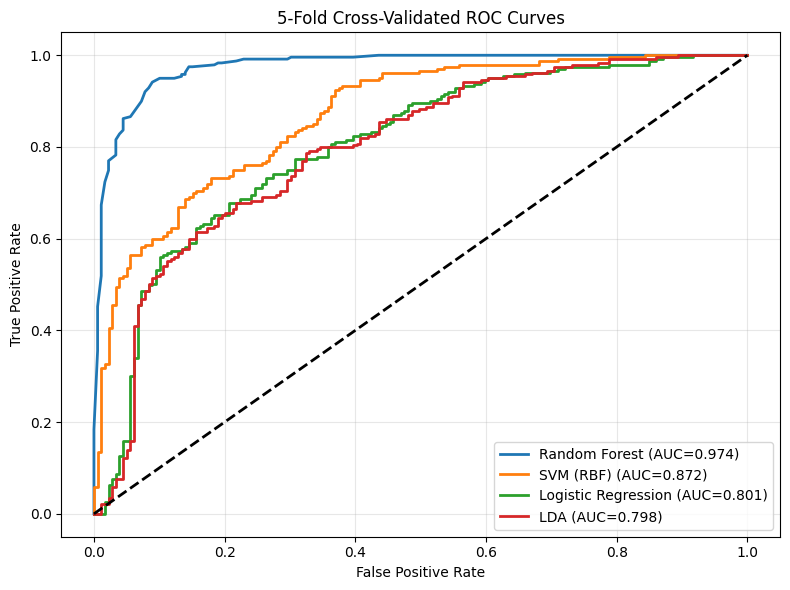

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'
data = pd.read_csv(file_path)

X = data.drop(columns=['Sl. No:', 'Segment_Number', 'File_Name', 'label'])
y = data['label'].map({"before_HI": 0, "during_HI": 1})

# ======================================================
# ✅ FINAL FEATURE SET
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"

]

X_final = X[sig_features]

# ======================================================
# ✅ 5-FOLD STRATIFIED CV
# ======================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=3)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=3),
    "SVM (RBF)": SVC(kernel='rbf', C=1.0, gamma='scale',
                     probability=True, random_state=3),
    "Logistic Regression": LogisticRegression(C=1.0,
                                              solver='liblinear',
                                              penalty='l2',
                                              random_state=3),
    "LDA": LDA()
}

# ======================================================
# ✅ RUN 5-FOLD CV
# ======================================================
plt.figure(figsize=(8, 6))

for name, model in models.items():

    fold_aucs = []
    y_true_all = []
    y_prob_all = []

    print("\n========================================")
    print(f"{name} — 5-Fold Cross-Validation")
    print("========================================")

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_final, y), 1):

        X_train, X_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Scale for linear/SVM models
        if name in ["SVM (RBF)", "Logistic Regression", "LDA"]:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # Train
        model.fit(X_train, y_train)

        # Predict probabilities
        probs = model.predict_proba(X_test)[:, 1]

        # Compute fold AUC
        fold_auc = roc_auc_score(y_test, probs)
        fold_aucs.append(fold_auc)

        print(f"Fold {fold} AUC: {fold_auc:.4f}")

        # Store for overall ROC curve
        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # Convert to arrays
    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    print(f"\nMean AUC ± SD: {mean_auc:.4f} ± {std_auc:.4f}")

    # Compute pooled ROC curve
    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)

    plt.plot(fpr, tpr, lw=2,
             label=f"{name} (AUC={mean_auc:.3f})")

# Diagonal reference
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("5-Fold Cross-Validated ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Random Forest — 5-Fold Cross-Validation
Fold 1 AUC: 0.9899
Fold 2 AUC: 0.9638
Fold 3 AUC: 0.9832
Fold 4 AUC: 0.9423
Fold 5 AUC: 0.9885

Mean AUC ± SD: 0.9735 ± 0.0182

SVM (RBF) — 5-Fold Cross-Validation
Fold 1 AUC: 0.9010
Fold 2 AUC: 0.8987
Fold 3 AUC: 0.8837
Fold 4 AUC: 0.8048
Fold 5 AUC: 0.8741

Mean AUC ± SD: 0.8725 ± 0.0353

Logistic Regression — 5-Fold Cross-Validation
Fold 1 AUC: 0.8547
Fold 2 AUC: 0.7598
Fold 3 AUC: 0.8646
Fold 4 AUC: 0.7333
Fold 5 AUC: 0.7902

Mean AUC ± SD: 0.8005 ± 0.0516

LDA — 5-Fold Cross-Validation
Fold 1 AUC: 0.8605
Fold 2 AUC: 0.7656
Fold 3 AUC: 0.8756
Fold 4 AUC: 0.7202
Fold 5 AUC: 0.7665

Mean AUC ± SD: 0.7977 ± 0.0600


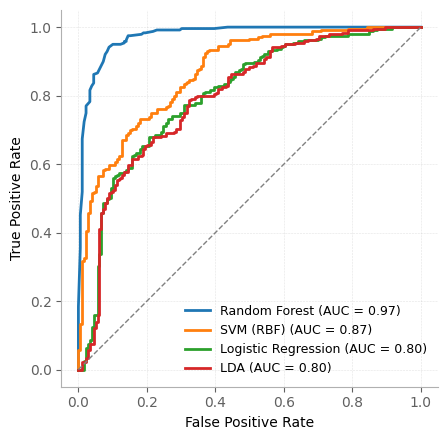

In [ ]:
# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'
data = pd.read_csv(file_path)

X = data.drop(columns=['Sl. No:', 'Segment_Number', 'File_Name', 'label'])
y = data['label'].map({"before_HI": 0, "during_HI": 1})


# ======================================================
# ✅ FINAL FEATURE SET
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"
]

X_final = X[sig_features]


# ======================================================
# ✅ 5-FOLD STRATIFIED CROSS-VALIDATION
# ======================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=3)

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=50, random_state=3
    ),
    "SVM (RBF)": SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=3
    ),
    "Logistic Regression": LogisticRegression(
        C=1.0,
        solver='liblinear',
        penalty='l2',
        random_state=3
    ),
    "LDA": LDA()
}


# ======================================================
# ✅ PLOT (Clean Journal Style)
# ======================================================
fig, ax = plt.subplots(figsize=(5.5, 4.5))

for name, model in models.items():

    fold_aucs = []
    y_true_all = []
    y_prob_all = []

    print("\n========================================")
    print(f"{name} — 5-Fold Cross-Validation")
    print("========================================")

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_final, y), 1):

        X_train = X_final.iloc[train_idx]
        X_test = X_final.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Scale for SVM / LR / LDA
        if name in ["SVM (RBF)", "Logistic Regression", "LDA"]:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # Train model
        model.fit(X_train, y_train)

        # Predict probabilities
        probs = model.predict_proba(X_test)[:, 1]

        # Fold AUC
        fold_auc = roc_auc_score(y_test, probs)
        fold_aucs.append(fold_auc)

        print(f"Fold {fold} AUC: {fold_auc:.4f}")

        # Store predictions
        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    print(f"\nMean AUC ± SD: {mean_auc:.4f} ± {std_auc:.4f}")

    # Compute pooled ROC
    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)

    # Plot ROC curve (2-decimal AUC for journal clarity)
    ax.plot(fpr, tpr, lw=2,
            label=f"{name} (AUC = {mean_auc:.2f})")


# ======================================================
# Diagonal Reference Line
# ======================================================
ax.plot([0, 1], [0, 1],
        linestyle='--',
        linewidth=1,
        color='gray')


# ======================================================
# Styling (Elsevier Clean Look)
# ======================================================
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Light thin axes
ax.spines['left'].set_color('#B0B0B0')
ax.spines['bottom'].set_color('#B0B0B0')
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# Light ticks
ax.tick_params(colors='#606060', width=0.8)

# Light thin grid
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.35)

# Legend without frame
ax.legend(frameon=False, fontsize=9, loc="lower right")

# Square ROC look
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


Subject wise Analysis


Random Forest — Subject-wise 5-Fold CV
Fold 1 AUC: 0.6198
Fold 2 AUC: 0.7365
Fold 3 AUC: 0.6889
Fold 4 AUC: 0.1574
Fold 5 AUC: 0.8213

Mean AUC ± SD: 0.6048 ± 0.2331

SVM (RBF) — Subject-wise 5-Fold CV
Fold 1 AUC: 0.2927
Fold 2 AUC: 0.8034
Fold 3 AUC: 0.6840
Fold 4 AUC: 0.4461
Fold 5 AUC: 0.7674

Mean AUC ± SD: 0.5987 ± 0.1973

Logistic Regression — Subject-wise 5-Fold CV
Fold 1 AUC: 0.5847
Fold 2 AUC: 0.4713
Fold 3 AUC: 0.7867
Fold 4 AUC: 0.3088
Fold 5 AUC: 0.5826

Mean AUC ± SD: 0.5468 ± 0.1566

LDA — Subject-wise 5-Fold CV
Fold 1 AUC: 0.5418
Fold 2 AUC: 0.5121
Fold 3 AUC: 0.7851
Fold 4 AUC: 0.2971
Fold 5 AUC: 0.6393

Mean AUC ± SD: 0.5551 ± 0.1604


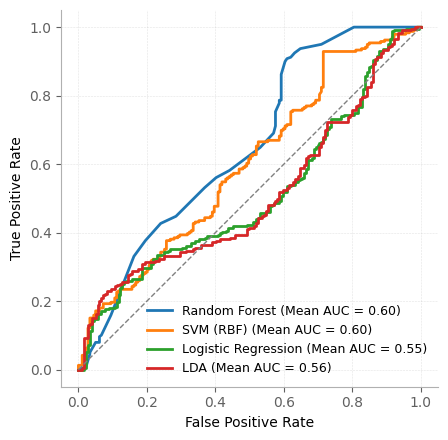

In [ ]:
# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'
data = pd.read_csv(file_path)

# Features & labels
X = data.drop(columns=['Sl. No:', 'Segment_Number', 'File_Name', 'label'])
y = data['label'].map({"before_HI": 0, "during_HI": 1})


# ======================================================
# ✅ EXTRACT SUBJECT IDS (CRITICAL STEP)
# ======================================================
# Adjust this depending on your filename structure
# Example: S01_xxx → subject = S01

data['subject_id'] = data['File_Name'].apply(lambda x: str(x).split('_')[0])
groups = data['subject_id']


# ======================================================
# ✅ FINAL FEATURE SET (Compact Biomarker Set)
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"
]

X_final = X[sig_features]


# ======================================================
# ✅ MODELS
# ======================================================
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=50, random_state=3
    ),
    "SVM (RBF)": SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=3
    ),
    "Logistic Regression": LogisticRegression(
        C=1.0,
        solver='liblinear',
        penalty='l2',
        random_state=3
    ),
    "LDA": LDA()
}


# ======================================================
# ✅ SUBJECT-WISE CROSS-VALIDATION
# ======================================================
gkf = GroupKFold(n_splits=5)

fig, ax = plt.subplots(figsize=(5.5, 4.5))

for name, model in models.items():

    fold_aucs = []
    y_true_all = []
    y_prob_all = []

    print("\n========================================")
    print(f"{name} — Subject-wise 5-Fold CV")
    print("========================================")

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_final, y, groups), 1):

        X_train = X_final.iloc[train_idx]
        X_test = X_final.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # ======================================================
        # ✅ SCALE (only for specific models)
        # ======================================================
        if name in ["SVM (RBF)", "Logistic Regression", "LDA"]:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # ======================================================
        # ✅ TRAIN
        # ======================================================
        model.fit(X_train, y_train)

        # ======================================================
        # ✅ PREDICT
        # ======================================================
        probs = model.predict_proba(X_test)[:, 1]

        # ======================================================
        # ✅ AUC
        # ======================================================
        fold_auc = roc_auc_score(y_test, probs)
        fold_aucs.append(fold_auc)

        print(f"Fold {fold} AUC: {fold_auc:.4f}")

        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # Convert to numpy
    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    # ======================================================
    # ✅ MEAN PERFORMANCE
    # ======================================================
    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    print(f"\nMean AUC ± SD: {mean_auc:.4f} ± {std_auc:.4f}")

    # ======================================================
    # ✅ ROC CURVE
    # ======================================================
    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)

    ax.plot(fpr, tpr, lw=2,
            label=f"{name} (Mean AUC = {mean_auc:.2f})")


# ======================================================
# ✅ DIAGONAL LINE
# ======================================================
ax.plot([0, 1], [0, 1],
        linestyle='--',
        linewidth=1,
        color='gray')


# ======================================================
# ✅ STYLING (JOURNAL QUALITY)
# ======================================================
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#B0B0B0')
ax.spines['bottom'].set_color('#B0B0B0')
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

ax.tick_params(colors='#606060', width=0.8)

ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.35)

ax.legend(frameon=False, fontsize=9, loc="lower right")

ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

Subject wise improved with patient normalization

/tmp/ipykernel_17287/1936810719.py:59: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 1.32948458e+00  1.39423103e+00 -2.56803315e-01  6.69289092e-02
  5.20154023e-01 -3.21549760e-01 -3.01907580e-02 -3.53922982e-01
  2.28795021e-01 -5.80535539e-01 -4.51042649e-01 -2.24430092e-01
 -6.12908761e-01  1.58847036e+00  6.69289092e-02 -9.49372028e-02
 -7.10028428e-01  1.10287203e+00 -3.86296204e-01 -1.74597155e+00
 -4.51042649e-01 -9.04267763e-01  1.55609714e+00  1.52372392e+00
 -2.23156988e+00 -2.26394310e+00 -4.18669427e-01  1.39423103e+00
 -6.25639804e-02  1.39423103e+00 -5.80535539e-01  3.45556868e-02
 -6.12908761e-01  2.18246443e-03  1.52372392e+00 -9.49372028e-02
 -6.77655206e-01 -1.27310425e-01  1.45897747e+00  9.93021316e-02
 -1.59683648e-01  9.93021316e-02 -1.64885188e+00  1.49135069e+00
  6.82020135e-01  1.26473814e+00 -6.25639804e-02  6.69289092e-02
  4.55407578e-01 -7.42401651e-01 -3.86296204e-01 -5.


Random Forest — Subject-wise (Improved)
Fold 1 AUC: 0.6881
Fold 2 AUC: 0.9533
Fold 3 AUC: 0.8203
Fold 4 AUC: 0.6195
Fold 5 AUC: 0.6847

Mean AUC ± SD: 0.7532 ± 0.1195

SVM (RBF) — Subject-wise (Improved)
Fold 1 AUC: 0.7466
Fold 2 AUC: 0.9267
Fold 3 AUC: 0.8214
Fold 4 AUC: 0.7598
Fold 5 AUC: 0.7153

Mean AUC ± SD: 0.7939 ± 0.0748

Logistic Regression — Subject-wise (Improved)
Fold 1 AUC: 0.6929
Fold 2 AUC: 0.9800
Fold 3 AUC: 0.4487
Fold 4 AUC: 0.4753
Fold 5 AUC: 0.7418

Mean AUC ± SD: 0.6677 ± 0.1942

LDA — Subject-wise (Improved)
Fold 1 AUC: 0.7081
Fold 2 AUC: 0.9756
Fold 3 AUC: 0.4193
Fold 4 AUC: 0.4816
Fold 5 AUC: 0.7469

Mean AUC ± SD: 0.6663 ± 0.1995


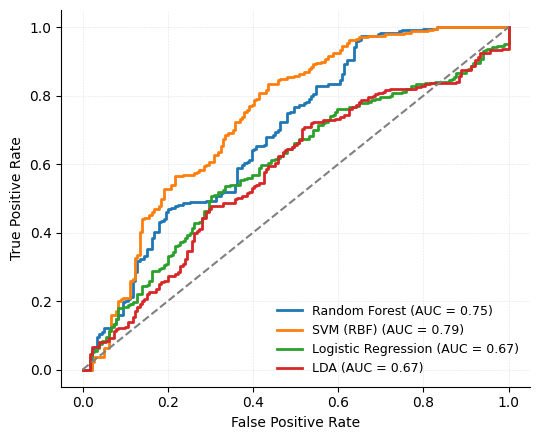

In [ ]:
# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'
data = pd.read_csv(file_path)

# Labels
data['label'] = data['label'].map({"before_HI": 0, "during_HI": 1})

# ======================================================
# ✅ EXTRACT SUBJECT ID
# ======================================================
data['subject_id'] = data['File_Name'].apply(lambda x: str(x).split('_')[0])


# ======================================================
# ✅ FEATURE SET
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"
]


# ======================================================
# ✅ 1️⃣ SUBJECT-WISE NORMALIZATION
# ======================================================
X_norm = data.copy()

for subject in X_norm['subject_id'].unique():
    idx = X_norm['subject_id'] == subject
    scaler = StandardScaler()
    X_norm.loc[idx, sig_features] = scaler.fit_transform(
        X_norm.loc[idx, sig_features]
    )


# ======================================================
# ✅ 2️⃣ RELATIVE FEATURE TRANSFORMATION
# (Difference from subject baseline: before_HI)
# ======================================================
X_rel = X_norm.copy()

for subject in X_rel['subject_id'].unique():
    idx = X_rel['subject_id'] == subject

    subject_data = X_rel.loc[idx]

    # Baseline = before_HI
    baseline = subject_data[subject_data['label'] == 0][sig_features].mean()

    # Subtract baseline
    X_rel.loc[idx, sig_features] = subject_data[sig_features] - baseline


# Final X and y
X_final = X_rel[sig_features]
y = X_rel['label']
groups = X_rel['subject_id']


# ======================================================
# ✅ MODELS (IMPROVED RF)
# ======================================================
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=3
    ),
    "SVM (RBF)": SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=3
    ),
    "Logistic Regression": LogisticRegression(
        C=1.0,
        solver='liblinear',
        penalty='l2',
        class_weight='balanced',
        random_state=3
    ),
    "LDA": LDA()
}


# ======================================================
# ✅ 3️⃣ STRATIFIED GROUP K-FOLD
# ======================================================
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=3)


# ======================================================
# ✅ PLOT
# ======================================================
fig, ax = plt.subplots(figsize=(5.5, 4.5))

for name, model in models.items():

    fold_aucs = []
    y_true_all = []
    y_prob_all = []

    print("\n========================================")
    print(f"{name} — Subject-wise (Improved)")
    print("========================================")

    for fold, (train_idx, test_idx) in enumerate(
            sgkf.split(X_final, y, groups), 1):

        X_train = X_final.iloc[train_idx]
        X_test = X_final.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Scale again for models that need global scaling
        if name in ["SVM (RBF)", "Logistic Regression", "LDA"]:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # Train
        model.fit(X_train, y_train)

        # Predict
        probs = model.predict_proba(X_test)[:, 1]

        # AUC
        fold_auc = roc_auc_score(y_test, probs)
        fold_aucs.append(fold_auc)

        print(f"Fold {fold} AUC: {fold_auc:.4f}")

        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # Mean performance
    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    print(f"\nMean AUC ± SD: {mean_auc:.4f} ± {std_auc:.4f}")

    # ROC
    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)

    ax.plot(fpr, tpr, lw=2,
            label=f"{name} (AUC = {mean_auc:.2f})")


# ======================================================
# ✅ STYLE
# ======================================================
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.35)

ax.legend(frameon=False, fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

LOSO


Random Forest — LOSO Validation
Subject 1 AUC: 0.8722
Subject 2 AUC: 0.6195
Subject 3 AUC: 0.6847
Subject 4 AUC: 0.9533
Subject 5 AUC: 0.6716
Subject 6 AUC: 0.6881

Mean LOSO AUC ± SD: 0.7482 ± 0.1208

SVM (RBF) — LOSO Validation
Subject 1 AUC: 0.8289
Subject 2 AUC: 0.7598
Subject 3 AUC: 0.7153
Subject 4 AUC: 0.9267
Subject 5 AUC: 0.7343
Subject 6 AUC: 0.7466

Mean LOSO AUC ± SD: 0.7852 ± 0.0725

Logistic Regression — LOSO Validation
Subject 1 AUC: 0.2767
Subject 2 AUC: 0.4753
Subject 3 AUC: 0.7418
Subject 4 AUC: 0.9800
Subject 5 AUC: 0.1627
Subject 6 AUC: 0.6929

Mean LOSO AUC ± SD: 0.5549 ± 0.2805

LDA — LOSO Validation
Subject 1 AUC: 0.2600
Subject 2 AUC: 0.4816
Subject 3 AUC: 0.7469
Subject 4 AUC: 0.9756
Subject 5 AUC: 0.1676
Subject 6 AUC: 0.7081

Mean LOSO AUC ± SD: 0.5566 ± 0.2827


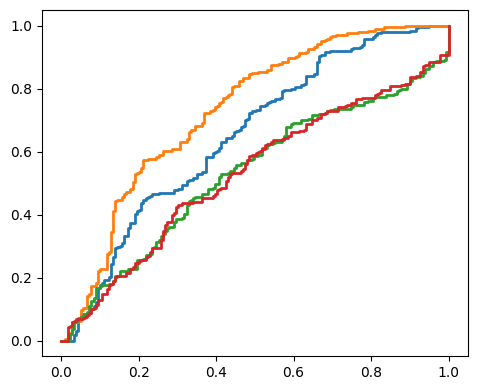

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

logo = LeaveOneGroupOut()

fig, ax = plt.subplots(figsize=(5.5, 4.5))

for name, model in models.items():

    y_true_all = []
    y_prob_all = []
    aucs = []

    print("\n========================================")
    print(f"{name} — LOSO Validation")
    print("========================================")

    for fold, (train_idx, test_idx) in enumerate(
            logo.split(X_final, y, groups), 1):

        X_train = X_final.iloc[train_idx]
        X_test = X_final.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Scaling (important)
        if name in ["SVM (RBF)", "Logistic Regression", "LDA"]:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        model.fit(X_train, y_train)

        probs = model.predict_proba(X_test)[:, 1]

        # Handle edge case (only one class in test)
        if len(np.unique(y_test)) < 2:
            continue

        auc = roc_auc_score(y_test, probs)
        aucs.append(auc)

        print(f"Subject {fold} AUC: {auc:.4f}")

        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    print(f"\nMean LOSO AUC ± SD: {mean_auc:.4f} ± {std_auc:.4f}")

    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)

    ax.plot(fpr, tpr, lw=2,
            label=f"{name} (AUC = {mean_auc:.2f})")

Subject wise again improved

/tmp/ipykernel_6004/2736851960.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 1.32948458e+00  1.39423103e+00 -2.56803315e-01  6.69289092e-02
  5.20154023e-01 -3.21549760e-01 -3.01907580e-02 -3.53922982e-01
  2.28795021e-01 -5.80535539e-01 -4.51042649e-01 -2.24430092e-01
 -6.12908761e-01  1.58847036e+00  6.69289092e-02 -9.49372028e-02
 -7.10028428e-01  1.10287203e+00 -3.86296204e-01 -1.74597155e+00
 -4.51042649e-01 -9.04267763e-01  1.55609714e+00  1.52372392e+00
 -2.23156988e+00 -2.26394310e+00 -4.18669427e-01  1.39423103e+00
 -6.25639804e-02  1.39423103e+00 -5.80535539e-01  3.45556868e-02
 -6.12908761e-01  2.18246443e-03  1.52372392e+00 -9.49372028e-02
 -6.77655206e-01 -1.27310425e-01  1.45897747e+00  9.93021316e-02
 -1.59683648e-01  9.93021316e-02 -1.64885188e+00  1.49135069e+00
  6.82020135e-01  1.26473814e+00 -6.25639804e-02  6.69289092e-02
  4.55407578e-01 -7.42401651e-01 -3.86296204e-01 -5.8


Random Forest — Subject-wise (Final Clean)
Fold 1 AUC: 0.9000
Fold 2 AUC: 0.5977
Fold 3 AUC: 0.7609
Fold 4 AUC: 0.6605
Fold 5 AUC: 0.7088

Mean AUC ± SD: 0.7256 ± 0.1025

SVM (RBF) — Subject-wise (Final Clean)
Fold 1 AUC: 0.9156
Fold 2 AUC: 0.7046
Fold 3 AUC: 0.8512
Fold 4 AUC: 0.7192
Fold 5 AUC: 0.7225

Mean AUC ± SD: 0.7826 ± 0.0850

Logistic Regression — Subject-wise (Final Clean)
Fold 1 AUC: 0.9800
Fold 2 AUC: 0.4759
Fold 3 AUC: 0.5521
Fold 4 AUC: 0.7429
Fold 5 AUC: 0.1608

Mean AUC ± SD: 0.5823 ± 0.2735

LDA — Subject-wise (Final Clean)
Fold 1 AUC: 0.9756
Fold 2 AUC: 0.4816
Fold 3 AUC: 0.5431
Fold 4 AUC: 0.7469
Fold 5 AUC: 0.1676

Mean AUC ± SD: 0.5830 ± 0.2703


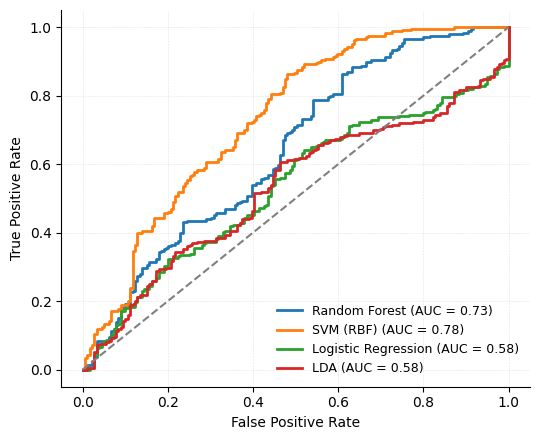

In [ ]:
# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'
data = pd.read_csv(file_path)

# Labels
data['label'] = data['label'].map({"before_HI": 0, "during_HI": 1})

# ======================================================
# ✅ EXTRACT SUBJECT ID
# ======================================================
data['subject_id'] = data['File_Name'].apply(lambda x: str(x).split('_')[0])


# ======================================================
# ✅ FEATURE SET
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"
]


# ======================================================
# ✅ 1️⃣ SUBJECT-WISE NORMALIZATION
# ======================================================
X_norm = data.copy()

for subject in X_norm['subject_id'].unique():
    idx = X_norm['subject_id'] == subject

    scaler = StandardScaler()
    X_norm.loc[idx, sig_features] = scaler.fit_transform(
        X_norm.loc[idx, sig_features]
    )


# ======================================================
# ✅ 2️⃣ RELATIVE FEATURE TRANSFORMATION
# ======================================================
X_rel = X_norm.copy()

for subject in X_rel['subject_id'].unique():
    idx = X_rel['subject_id'] == subject
    subject_data = X_rel.loc[idx]

    baseline_data = subject_data[subject_data['label'] == 0]

    # ✅ FIX: handle missing baseline safely
    if len(baseline_data) == 0:
        continue

    baseline = baseline_data[sig_features].mean()

    X_rel.loc[idx, sig_features] = subject_data[sig_features] - baseline


# ======================================================
# ✅ FINAL DATA
# ======================================================
X_final = X_rel[sig_features]
y = X_rel['label']
groups = X_rel['subject_id']


# ======================================================
# ✅ MODELS (REPRODUCIBLE)
# ======================================================
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),
    "SVM (RBF)": SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        C=1.0,
        solver='liblinear',
        penalty='l2',
        class_weight='balanced',
        random_state=42
    ),
    "LDA": LDA()
}


# ======================================================
# ✅ STRATIFIED GROUP K-FOLD
# ======================================================
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)


# ======================================================
# ✅ PLOT
# ======================================================
fig, ax = plt.subplots(figsize=(5.5, 4.5))

for name, model in models.items():

    fold_aucs = []
    y_true_all = []
    y_prob_all = []

    print("\n========================================")
    print(f"{name} — Subject-wise (Final Clean)")
    print("========================================")

    for fold, (train_idx, test_idx) in enumerate(
            sgkf.split(X_final, y, groups), 1):

        X_train = X_final.iloc[train_idx]
        X_test = X_final.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # ======================================================
        # ✅ TRAIN
        # ======================================================
        model.fit(X_train, y_train)

        # ======================================================
        # ✅ PREDICT
        # ======================================================
        probs = model.predict_proba(X_test)[:, 1]

        # Skip invalid fold
        if len(np.unique(y_test)) < 2:
            continue

        fold_auc = roc_auc_score(y_test, probs)
        fold_aucs.append(fold_auc)

        print(f"Fold {fold} AUC: {fold_auc:.4f}")

        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # ======================================================
    # ✅ FINAL METRICS
    # ======================================================
    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    print(f"\nMean AUC ± SD: {mean_auc:.4f} ± {std_auc:.4f}")

    # ROC
    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)

    ax.plot(fpr, tpr, lw=2,
            label=f"{name} (AUC = {mean_auc:.2f})")


# ======================================================
# ✅ STYLE
# ======================================================
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.35)

ax.legend(frameon=False, fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

/tmp/ipykernel_17898/1936810719.py:59: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 1.32948458e+00  1.39423103e+00 -2.56803315e-01  6.69289092e-02
  5.20154023e-01 -3.21549760e-01 -3.01907580e-02 -3.53922982e-01
  2.28795021e-01 -5.80535539e-01 -4.51042649e-01 -2.24430092e-01
 -6.12908761e-01  1.58847036e+00  6.69289092e-02 -9.49372028e-02
 -7.10028428e-01  1.10287203e+00 -3.86296204e-01 -1.74597155e+00
 -4.51042649e-01 -9.04267763e-01  1.55609714e+00  1.52372392e+00
 -2.23156988e+00 -2.26394310e+00 -4.18669427e-01  1.39423103e+00
 -6.25639804e-02  1.39423103e+00 -5.80535539e-01  3.45556868e-02
 -6.12908761e-01  2.18246443e-03  1.52372392e+00 -9.49372028e-02
 -6.77655206e-01 -1.27310425e-01  1.45897747e+00  9.93021316e-02
 -1.59683648e-01  9.93021316e-02 -1.64885188e+00  1.49135069e+00
  6.82020135e-01  1.26473814e+00 -6.25639804e-02  6.69289092e-02
  4.55407578e-01 -7.42401651e-01 -3.86296204e-01 -5.


Random Forest — Subject-wise (Improved)
Fold 1 AUC: 0.6881
Fold 2 AUC: 0.9533
Fold 3 AUC: 0.8203
Fold 4 AUC: 0.6195
Fold 5 AUC: 0.6847

Mean AUC ± SD: 0.7532 ± 0.1195

SVM (RBF) — Subject-wise (Improved)
Fold 1 AUC: 0.7466
Fold 2 AUC: 0.9267
Fold 3 AUC: 0.8214
Fold 4 AUC: 0.7598
Fold 5 AUC: 0.7153

Mean AUC ± SD: 0.7939 ± 0.0748

Logistic Regression — Subject-wise (Improved)
Fold 1 AUC: 0.6929
Fold 2 AUC: 0.9800
Fold 3 AUC: 0.4487
Fold 4 AUC: 0.4753
Fold 5 AUC: 0.7418

Mean AUC ± SD: 0.6677 ± 0.1942

LDA — Subject-wise (Improved)
Fold 1 AUC: 0.7081
Fold 2 AUC: 0.9756
Fold 3 AUC: 0.4193
Fold 4 AUC: 0.4816
Fold 5 AUC: 0.7469

Mean AUC ± SD: 0.6663 ± 0.1995


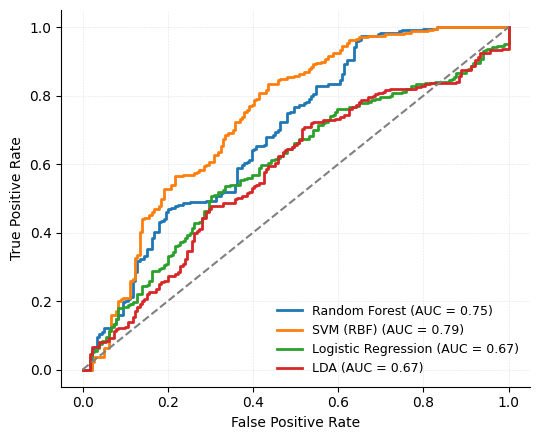

In [ ]:
# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'
data = pd.read_csv(file_path)

# Labels
data['label'] = data['label'].map({"before_HI": 0, "during_HI": 1})

# ======================================================
# ✅ EXTRACT SUBJECT ID
# ======================================================
data['subject_id'] = data['File_Name'].apply(lambda x: str(x).split('_')[0])


# ======================================================
# ✅ FEATURE SET
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"
]


# ======================================================
# ✅ 1️⃣ SUBJECT-WISE NORMALIZATION
# ======================================================
X_norm = data.copy()

for subject in X_norm['subject_id'].unique():
    idx = X_norm['subject_id'] == subject
    scaler = StandardScaler()
    X_norm.loc[idx, sig_features] = scaler.fit_transform(
        X_norm.loc[idx, sig_features]
    )


# ======================================================
# ✅ 2️⃣ RELATIVE FEATURE TRANSFORMATION
# (Difference from subject baseline: before_HI)
# ======================================================
X_rel = X_norm.copy()

for subject in X_rel['subject_id'].unique():
    idx = X_rel['subject_id'] == subject

    subject_data = X_rel.loc[idx]

    # Baseline = before_HI
    baseline = subject_data[subject_data['label'] == 0][sig_features].mean()

    # Subtract baseline
    X_rel.loc[idx, sig_features] = subject_data[sig_features] - baseline


# Final X and y
X_final = X_rel[sig_features]
y = X_rel['label']
groups = X_rel['subject_id']


# ======================================================
# ✅ MODELS (IMPROVED RF)
# ======================================================
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=3
    ),
    "SVM (RBF)": SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=3
    ),
    "Logistic Regression": LogisticRegression(
        C=1.0,
        solver='liblinear',
        penalty='l2',
        class_weight='balanced',
        random_state=3
    ),
    "LDA": LDA()
}


# ======================================================
# ✅ 3️⃣ STRATIFIED GROUP K-FOLD
# ======================================================
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=3)


# ======================================================
# ✅ PLOT
# ======================================================
fig, ax = plt.subplots(figsize=(5.5, 4.5))

for name, model in models.items():

    fold_aucs = []
    y_true_all = []
    y_prob_all = []

    print("\n========================================")
    print(f"{name} — Subject-wise (Improved)")
    print("========================================")

    for fold, (train_idx, test_idx) in enumerate(
            sgkf.split(X_final, y, groups), 1):

        X_train = X_final.iloc[train_idx]
        X_test = X_final.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Scale again for models that need global scaling
        if name in ["SVM (RBF)", "Logistic Regression", "LDA"]:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # Train
        model.fit(X_train, y_train)

        # Predict
        probs = model.predict_proba(X_test)[:, 1]

        # AUC
        fold_auc = roc_auc_score(y_test, probs)
        fold_aucs.append(fold_auc)

        print(f"Fold {fold} AUC: {fold_auc:.4f}")

        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # Mean performance
    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    print(f"\nMean AUC ± SD: {mean_auc:.4f} ± {std_auc:.4f}")

    # ROC
    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)

    ax.plot(fpr, tpr, lw=2,
            label=f"{name} (AUC = {mean_auc:.2f})")


# ======================================================
# ✅ STYLE
# ======================================================
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.35)

ax.legend(frameon=False, fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()


Random Forest — Subject-wise CV
Fold 1 AUC: 0.6419
Fold 2 AUC: 0.8778
Fold 3 AUC: 0.5154
Fold 4 AUC: 0.9184
Fold 5 AUC: 0.5483

Mean AUC ± SD: 0.7004 ± 0.1672

SVM (RBF) — Subject-wise CV
Fold 1 AUC: 0.5694
Fold 2 AUC: 0.8956
Fold 3 AUC: 0.6698
Fold 4 AUC: 0.8155
Fold 5 AUC: 0.3568

Mean AUC ± SD: 0.6614 ± 0.1897

Logistic Regression — Subject-wise CV
Fold 1 AUC: 0.7867
Fold 2 AUC: 0.9267
Fold 3 AUC: 0.5711
Fold 4 AUC: 0.4868
Fold 5 AUC: 0.5977

Mean AUC ± SD: 0.6738 ± 0.1600

LDA — Subject-wise CV
Fold 1 AUC: 0.7851
Fold 2 AUC: 0.9089
Fold 3 AUC: 0.6138
Fold 4 AUC: 0.5121
Fold 5 AUC: 0.5418

Mean AUC ± SD: 0.6723 ± 0.1515


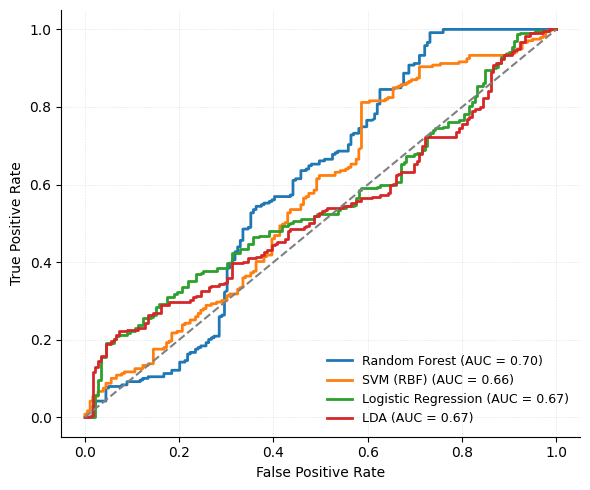

In [ ]:
# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'
data = pd.read_csv(file_path)

# Convert labels
data['label'] = data['label'].map({
    "before_HI": 0,
    "during_HI": 1
})

# ======================================================
# ✅ EXTRACT SUBJECT IDs
# ======================================================
data['subject_id'] = data['File_Name'].apply(
    lambda x: str(x).split('_')[0]
)

# ======================================================
# ✅ FINAL SELECTED FEATURES
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"
]

# ======================================================
# ✅ FEATURES / LABELS / GROUPS
# ======================================================
X = data[sig_features]
y = data['label']
groups = data['subject_id']


# ======================================================
# ✅ MODELS
# ======================================================
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=3
    ),

    "SVM (RBF)": SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=3
    ),

    "Logistic Regression": LogisticRegression(
        C=1.0,
        solver='liblinear',
        penalty='l2',
        class_weight='balanced',
        random_state=3
    ),

    "LDA": LDA()
}


# ======================================================
# ✅ SUBJECT-WISE CROSS-VALIDATION
# ======================================================
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=3
)


# ======================================================
# ✅ ROC PLOT
# ======================================================
fig, ax = plt.subplots(figsize=(6,5))

for name, model in models.items():

    fold_aucs = []

    y_true_all = []
    y_prob_all = []

    print("\n========================================")
    print(f"{name} — Subject-wise CV")
    print("========================================")

    for fold, (train_idx, test_idx) in enumerate(
            sgkf.split(X, y, groups), 1):

        # Split
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # ==================================================
        # ✅ SCALE ONLY USING TRAINING DATA
        # ==================================================
        if name in ["SVM (RBF)", "Logistic Regression", "LDA"]:

            scaler = StandardScaler()

            X_train = scaler.fit_transform(X_train)

            X_test = scaler.transform(X_test)

        # ==================================================
        # ✅ TRAIN MODEL
        # ==================================================
        model.fit(X_train, y_train)

        # ==================================================
        # ✅ PREDICT PROBABILITIES
        # ==================================================
        probs = model.predict_proba(X_test)[:, 1]

        # ==================================================
        # ✅ COMPUTE FOLD AUC
        # ==================================================
        fold_auc = roc_auc_score(y_test, probs)

        fold_aucs.append(fold_auc)

        print(f"Fold {fold} AUC: {fold_auc:.4f}")

        # Store for overall ROC
        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # ======================================================
    # ✅ FINAL MEAN AUC
    # ======================================================
    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    print(f"\nMean AUC ± SD: {mean_auc:.4f} ± {std_auc:.4f}")

    # ======================================================
    # ✅ ROC CURVE
    # ======================================================
    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)

    ax.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{name} (AUC = {mean_auc:.2f})"
    )


# ======================================================
# ✅ STYLE
# ======================================================
ax.plot([0,1], [0,1],
        linestyle='--',
        color='gray')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True,
        linestyle='--',
        linewidth=0.4,
        alpha=0.35)

ax.legend(frameon=False,
          fontsize=9,
          loc="lower right")

plt.tight_layout()
plt.show()

LOSO new

/tmp/ipykernel_1637/3086952431.py:57: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 1.32948458e+00  1.39423103e+00 -2.56803315e-01  6.69289092e-02
  5.20154023e-01 -3.21549760e-01 -3.01907580e-02 -3.53922982e-01
  2.28795021e-01 -5.80535539e-01 -4.51042649e-01 -2.24430092e-01
 -6.12908761e-01  1.58847036e+00  6.69289092e-02 -9.49372028e-02
 -7.10028428e-01  1.10287203e+00 -3.86296204e-01 -1.74597155e+00
 -4.51042649e-01 -9.04267763e-01  1.55609714e+00  1.52372392e+00
 -2.23156988e+00 -2.26394310e+00 -4.18669427e-01  1.39423103e+00
 -6.25639804e-02  1.39423103e+00 -5.80535539e-01  3.45556868e-02
 -6.12908761e-01  2.18246443e-03  1.52372392e+00 -9.49372028e-02
 -6.77655206e-01 -1.27310425e-01  1.45897747e+00  9.93021316e-02
 -1.59683648e-01  9.93021316e-02 -1.64885188e+00  1.49135069e+00
  6.82020135e-01  1.26473814e+00 -6.25639804e-02  6.69289092e-02
  4.55407578e-01 -7.42401651e-01 -3.86296204e-01 -5.8


Random Forest — LOSO Validation
Subject 1 AUC: 0.8733
Subject 2 AUC: 0.5977
Subject 3 AUC: 0.6605
Subject 4 AUC: 0.9000
Subject 5 AUC: 0.7088
Subject 6 AUC: 0.6856

Mean LOSO AUC ± SD: 0.7377 ± 0.1109

SVM (RBF) — LOSO Validation
Subject 1 AUC: 0.8100
Subject 2 AUC: 0.7046
Subject 3 AUC: 0.7192
Subject 4 AUC: 0.9156
Subject 5 AUC: 0.7225
Subject 6 AUC: 0.7506

Mean LOSO AUC ± SD: 0.7704 ± 0.0733

Logistic Regression — LOSO Validation
Subject 1 AUC: 0.2689
Subject 2 AUC: 0.4759
Subject 3 AUC: 0.7429
Subject 4 AUC: 0.9800
Subject 5 AUC: 0.1608
Subject 6 AUC: 0.6937

Mean LOSO AUC ± SD: 0.5537 ± 0.2825

LDA — LOSO Validation
Subject 1 AUC: 0.2600
Subject 2 AUC: 0.4816
Subject 3 AUC: 0.7469
Subject 4 AUC: 0.9756
Subject 5 AUC: 0.1676
Subject 6 AUC: 0.7081

Mean LOSO AUC ± SD: 0.5566 ± 0.2827


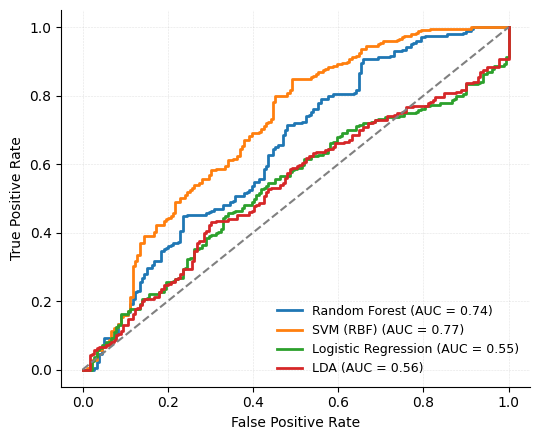

In [ ]:
# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'
data = pd.read_csv(file_path)

data['label'] = data['label'].map({"before_HI": 0, "during_HI": 1})

# Extract subject ID
data['subject_id'] = data['File_Name'].apply(lambda x: str(x).split('_')[0])


# ======================================================
# ✅ FEATURE SET
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"
]


# ======================================================
# ✅ 1️⃣ SUBJECT-WISE NORMALIZATION
# ======================================================
X_norm = data.copy()

for subject in X_norm['subject_id'].unique():
    idx = X_norm['subject_id'] == subject

    scaler = StandardScaler()
    X_norm.loc[idx, sig_features] = scaler.fit_transform(
        X_norm.loc[idx, sig_features]
    )


# ======================================================
# ✅ 2️⃣ RELATIVE FEATURE TRANSFORMATION
# ======================================================
X_rel = X_norm.copy()

for subject in X_rel['subject_id'].unique():
    idx = X_rel['subject_id'] == subject
    subject_data = X_rel.loc[idx]

    baseline_data = subject_data[subject_data['label'] == 0]

    # Handle missing baseline
    if len(baseline_data) == 0:
        continue

    baseline = baseline_data[sig_features].mean()

    X_rel.loc[idx, sig_features] = subject_data[sig_features] - baseline


# ======================================================
# ✅ FINAL DATA
# ======================================================
X_final = X_rel[sig_features]
y = X_rel['label']
groups = X_rel['subject_id']


# ======================================================
# ✅ MODELS
# ======================================================
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),
    "SVM (RBF)": SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ),
    "LDA": LDA()
}


# ======================================================
# ✅ LOSO CROSS-VALIDATION
# ======================================================
logo = LeaveOneGroupOut()

fig, ax = plt.subplots(figsize=(5.5, 4.5))

for name, model in models.items():

    print("\n========================================")
    print(f"{name} — LOSO Validation")
    print("========================================")

    aucs = []
    y_true_all = []
    y_prob_all = []

    for fold, (train_idx, test_idx) in enumerate(
            logo.split(X_final, y, groups), 1):

        X_train = X_final.iloc[train_idx]
        X_test = X_final.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Train
        model.fit(X_train, y_train)

        # Predict
        probs = model.predict_proba(X_test)[:, 1]

        # Skip if only one class
        if len(np.unique(y_test)) < 2:
            continue

        auc = roc_auc_score(y_test, probs)
        aucs.append(auc)

        print(f"Subject {fold} AUC: {auc:.4f}")

        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # Convert to numpy
    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    # Mean AUC
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    print(f"\nMean LOSO AUC ± SD: {mean_auc:.4f} ± {std_auc:.4f}")

    # ROC
    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)

    ax.plot(fpr, tpr, lw=2,
            label=f"{name} (AUC = {mean_auc:.2f})")


# ======================================================
# ✅ PLOT
# ======================================================
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.35)

ax.legend(frameon=False, fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

(Fold-wise Normalization)


Random Forest — LOSO Validation
Subject 1 AUC: 0.8956
Subject 2 AUC: 0.9362
Subject 3 AUC: 0.5571
Subject 4 AUC: 0.7956
Subject 5 AUC: 0.2270
Subject 6 AUC: 0.6391

Mean LOSO AUC ± SD: 0.6751 ± 0.2406

SVM (RBF) — LOSO Validation
Subject 1 AUC: 0.6733
Subject 2 AUC: 0.8155
Subject 3 AUC: 0.3571
Subject 4 AUC: 0.8956
Subject 5 AUC: 0.4676
Subject 6 AUC: 0.5694

Mean LOSO AUC ± SD: 0.6297 ± 0.1877

Logistic Regression — LOSO Validation
Subject 1 AUC: 0.5878
Subject 2 AUC: 0.4868
Subject 3 AUC: 0.5977
Subject 4 AUC: 0.9267
Subject 5 AUC: 0.3225
Subject 6 AUC: 0.7867

Mean LOSO AUC ± SD: 0.6180 ± 0.1956

LDA — LOSO Validation
Subject 1 AUC: 0.7122
Subject 2 AUC: 0.5121
Subject 3 AUC: 0.5418
Subject 4 AUC: 0.9089
Subject 5 AUC: 0.2971
Subject 6 AUC: 0.7851

Mean LOSO AUC ± SD: 0.6262 ± 0.2004


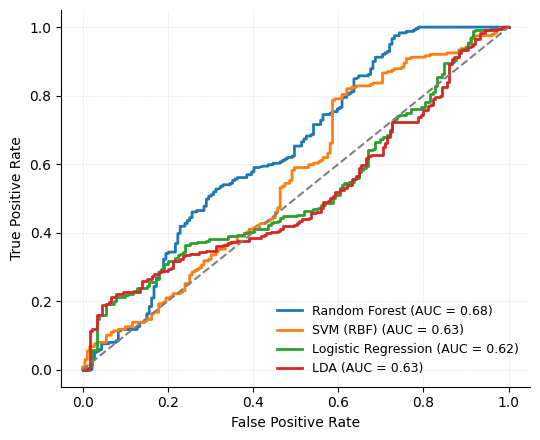

In [ ]:
# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


# ======================================================
# ✅ REPRODUCIBILITY
# ======================================================
np.random.seed(42)
random.seed(42)


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'
data = pd.read_csv(file_path)

data['label'] = data['label'].map({
    "before_HI": 0,
    "during_HI": 1
})

# Subject ID
data['subject_id'] = data['File_Name'].apply(
    lambda x: str(x).split('_')[0]
)


# ======================================================
# ✅ FEATURE SET
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"
]

X = data[sig_features]
y = data['label']
groups = data['subject_id']


# ======================================================
# ✅ MODELS
# ======================================================
models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),

    "SVM (RBF)": SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        class_weight='balanced',
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ),

    "LDA": LDA()
}


# ======================================================
# ✅ LOSO CROSS-VALIDATION
# ======================================================
logo = LeaveOneGroupOut()

fig, ax = plt.subplots(figsize=(5.5, 4.5))

for name, model in models.items():

    print("\n========================================")
    print(f"{name} — LOSO Validation")
    print("========================================")

    aucs = []
    y_true_all = []
    y_prob_all = []

    for fold, (train_idx, test_idx) in enumerate(
            logo.split(X, y, groups), 1):

        # -------------------------------------------------
        # RAW TRAIN / TEST SPLIT
        # -------------------------------------------------
        X_train_raw = X.iloc[train_idx]
        X_test_raw = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # -------------------------------------------------
        # ✅ FIX 1: NORMALIZATION INSIDE FOLD
        # Fit ONLY on training subjects
        # Apply to unseen test subject
        # -------------------------------------------------
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        # -------------------------------------------------
        # TRAIN MODEL
        # -------------------------------------------------
        model.fit(X_train, y_train)

        # -------------------------------------------------
        # PREDICT
        # -------------------------------------------------
        probs = model.predict_proba(X_test)[:, 1]

        # Skip invalid fold
        if len(np.unique(y_test)) < 2:
            continue

        # -------------------------------------------------
        # AUC
        # -------------------------------------------------
        auc = roc_auc_score(y_test, probs)
        aucs.append(auc)

        print(f"Subject {fold} AUC: {auc:.4f}")

        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # ======================================================
    # FINAL METRICS
    # ======================================================
    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    print(f"\nMean LOSO AUC ± SD: {mean_auc:.4f} ± {std_auc:.4f}")

    # ROC
    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)

    ax.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{name} (AUC = {mean_auc:.2f})"
    )


# ======================================================
# ✅ PLOT
# ======================================================
ax.plot([0, 1], [0, 1],
        linestyle='--',
        color='gray')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True,
        linestyle='--',
        linewidth=0.4,
        alpha=0.35)

ax.legend(frameon=False,
          fontsize=9,
          loc="lower right")

plt.tight_layout()
plt.show()

FULL LEAKAGE-FREE LOSO CODE


Random Forest — LOSO Validation
Subject 1 AUC: 0.8956
Subject 2 AUC: 0.9374
Subject 3 AUC: 0.5525
Subject 4 AUC: 0.8111
Subject 5 AUC: 0.2240
Subject 6 AUC: 0.6399

Mean LOSO AUC ± SD: 0.6768 ± 0.2434

SVM (RBF) — LOSO Validation
Subject 1 AUC: 0.7089
Subject 2 AUC: 0.6259
Subject 3 AUC: 0.5740
Subject 4 AUC: 0.9267
Subject 5 AUC: 0.5108
Subject 6 AUC: 0.7257

Mean LOSO AUC ± SD: 0.6787 ± 0.1333

Logistic Regression — LOSO Validation
Subject 1 AUC: 0.5833
Subject 2 AUC: 0.4874
Subject 3 AUC: 0.6011
Subject 4 AUC: 0.9267
Subject 5 AUC: 0.3265
Subject 6 AUC: 0.7867

Mean LOSO AUC ± SD: 0.6186 ± 0.1946

LDA — LOSO Validation
Subject 1 AUC: 0.7122
Subject 2 AUC: 0.5121
Subject 3 AUC: 0.5418
Subject 4 AUC: 0.9089
Subject 5 AUC: 0.2971
Subject 6 AUC: 0.7851

Mean LOSO AUC ± SD: 0.6262 ± 0.2004


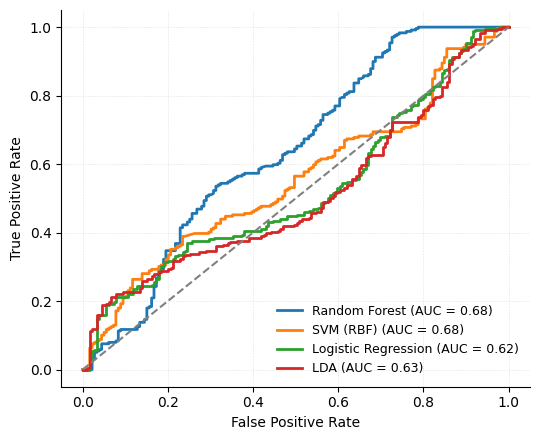

In [ ]:
# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


# ======================================================
# ✅ REPRODUCIBILITY
# ======================================================
np.random.seed(42)
random.seed(42)


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'

data = pd.read_csv(file_path)

data['label'] = data['label'].map({
    "before_HI": 0,
    "during_HI": 1
})

# Subject ID
data['subject_id'] = data['File_Name'].apply(
    lambda x: str(x).split('_')[0]
)


# ======================================================
# ✅ FEATURE SET
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"
]

X = data[sig_features]
y = data['label']
groups = data['subject_id']


# ======================================================
# ✅ MODELS
# ======================================================
models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),

    "SVM (RBF)": SVC(
        kernel='rbf',
        C=10,
        gamma=0.01,
        probability=True,
        class_weight='balanced',
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ),

    "LDA": LDA()
}


# ======================================================
# ✅ LOSO CROSS-VALIDATION
# ======================================================
logo = LeaveOneGroupOut()

fig, ax = plt.subplots(figsize=(5.5, 4.5))

for name, model in models.items():

    print("\n========================================")
    print(f"{name} — LOSO Validation")
    print("========================================")

    aucs = []

    y_true_all = []
    y_prob_all = []

    for fold, (train_idx, test_idx) in enumerate(
            logo.split(X, y, groups), 1):

        # -------------------------------------------------
        # RAW SPLIT
        # -------------------------------------------------
        X_train_raw = X.iloc[train_idx].copy()
        X_test_raw = X.iloc[test_idx].copy()

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # -------------------------------------------------
        # ✅ STEP 1: FOLD-WISE NORMALIZATION
        # Fit ONLY on training subjects
        # -------------------------------------------------
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        # Convert back to DataFrame
        X_train = pd.DataFrame(
            X_train,
            columns=sig_features,
            index=X_train_raw.index
        )

        X_test = pd.DataFrame(
            X_test,
            columns=sig_features,
            index=X_test_raw.index
        )

        # -------------------------------------------------
        # ✅ STEP 2: BASELINE-RELATIVE TRANSFORMATION
        # Estimate baseline ONLY from training data
        # -------------------------------------------------
        baseline_train = X_train[y_train == 0].mean(axis=0)

        X_train = X_train - baseline_train
        X_test = X_test - baseline_train

        # -------------------------------------------------
        # TRAIN MODEL
        # -------------------------------------------------
        model.fit(X_train, y_train)

        # -------------------------------------------------
        # PREDICT
        # -------------------------------------------------
        probs = model.predict_proba(X_test)[:, 1]

        # Skip invalid fold
        if len(np.unique(y_test)) < 2:
            continue

        # -------------------------------------------------
        # AUC
        # -------------------------------------------------
        auc = roc_auc_score(y_test, probs)

        aucs.append(auc)

        print(f"Subject {fold} AUC: {auc:.4f}")

        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # ======================================================
    # FINAL METRICS
    # ======================================================
    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    print(f"\nMean LOSO AUC ± SD: {mean_auc:.4f} ± {std_auc:.4f}")

    # ROC
    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)

    ax.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{name} (AUC = {mean_auc:.2f})"
    )


# ======================================================
# ✅ PLOT
# ======================================================
ax.plot([0, 1], [0, 1],
        linestyle='--',
        color='gray')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True,
        linestyle='--',
        linewidth=0.4,
        alpha=0.35)

ax.legend(frameon=False,
          fontsize=9,
          loc="lower right")

plt.tight_layout()
plt.show()

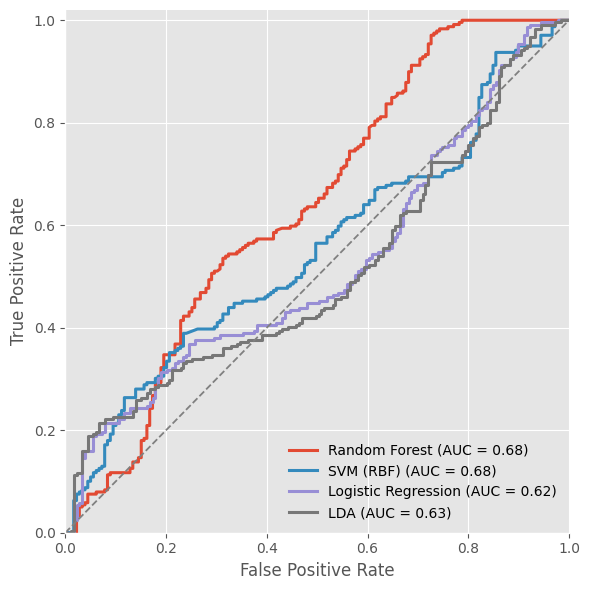

In [ ]:
# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


# ======================================================
# ✅ REPRODUCIBILITY
# ======================================================
np.random.seed(42)
random.seed(42)


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'

data = pd.read_csv(file_path)

data['label'] = data['label'].map({
    "before_HI": 0,
    "during_HI": 1
})

# Subject IDs
data['subject_id'] = data['File_Name'].apply(
    lambda x: str(x).split('_')[0]
)


# ======================================================
# ✅ FEATURE SET
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"
]

X = data[sig_features]
y = data['label']
groups = data['subject_id']


# ======================================================
# ✅ MODELS
# ======================================================
models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),

    "SVM (RBF)": SVC(
        kernel='rbf',
        C=10,
        gamma=0.01,
        probability=True,
        class_weight='balanced',
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ),

    "LDA": LDA()
}


# ======================================================
# ✅ FIGURE STYLE (MATCH TEMPLATE)
# ======================================================
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(6, 6))


# ======================================================
# ✅ LOSO CROSS-VALIDATION
# ======================================================
logo = LeaveOneGroupOut()

for name, model in models.items():

    aucs = []

    y_true_all = []
    y_prob_all = []

    for train_idx, test_idx in logo.split(X, y, groups):

        # -------------------------------------------------
        # SPLIT
        # -------------------------------------------------
        X_train_raw = X.iloc[train_idx]
        X_test_raw = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # -------------------------------------------------
        # ✅ FOLD-WISE NORMALIZATION
        # -------------------------------------------------
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        # -------------------------------------------------
        # BASELINE RELATIVE TRANSFORMATION
        # -------------------------------------------------
        X_train = pd.DataFrame(X_train, columns=sig_features)
        X_test = pd.DataFrame(X_test, columns=sig_features)

        baseline_train = X_train[y_train.values == 0].mean(axis=0)

        X_train = X_train - baseline_train
        X_test = X_test - baseline_train

        # -------------------------------------------------
        # TRAIN
        # -------------------------------------------------
        model.fit(X_train, y_train)

        # -------------------------------------------------
        # PREDICT
        # -------------------------------------------------
        probs = model.predict_proba(X_test)[:, 1]

        if len(np.unique(y_test)) < 2:
            continue

        auc = roc_auc_score(y_test, probs)
        aucs.append(auc)

        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # ======================================================
    # FINAL ROC
    # ======================================================
    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    mean_auc = np.mean(aucs)

    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)

    ax.plot(
        fpr,
        tpr,
        lw=2.2,
        label=f"{name} (AUC = {mean_auc:.2f})"
    )


# ======================================================
# ✅ DIAGONAL LINE
# ======================================================
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray',
    linewidth=1.3
)


# ======================================================
# ✅ AXIS LABELS
# ======================================================
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)


# ======================================================
# ✅ LIMITS
# ======================================================
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])


# ======================================================
# ✅ LEGEND
# ======================================================
ax.legend(
    loc='lower right',
    fontsize=10,
    frameon=False
)


# ======================================================
# ✅ CLEAN LOOK
# ======================================================
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


Random Forest — LOSO Validation
Subject 1 AUC: 0.8956
Subject 2 AUC: 0.9374
Subject 3 AUC: 0.5525
Subject 4 AUC: 0.8111
Subject 5 AUC: 0.2240
Subject 6 AUC: 0.6399

Mean LOSO AUC ± SD: 0.6768 ± 0.2434

SVM (RBF) — LOSO Validation
Subject 1 AUC: 0.7089
Subject 2 AUC: 0.6259
Subject 3 AUC: 0.5740
Subject 4 AUC: 0.9267
Subject 5 AUC: 0.5108
Subject 6 AUC: 0.7257

Mean LOSO AUC ± SD: 0.6787 ± 0.1333

Logistic Regression — LOSO Validation
Subject 1 AUC: 0.5833
Subject 2 AUC: 0.4874
Subject 3 AUC: 0.6011
Subject 4 AUC: 0.9267
Subject 5 AUC: 0.3265
Subject 6 AUC: 0.7867

Mean LOSO AUC ± SD: 0.6186 ± 0.1946

LDA — LOSO Validation
Subject 1 AUC: 0.7122
Subject 2 AUC: 0.5121
Subject 3 AUC: 0.5418
Subject 4 AUC: 0.9089
Subject 5 AUC: 0.2971
Subject 6 AUC: 0.7851

Mean LOSO AUC ± SD: 0.6262 ± 0.2004


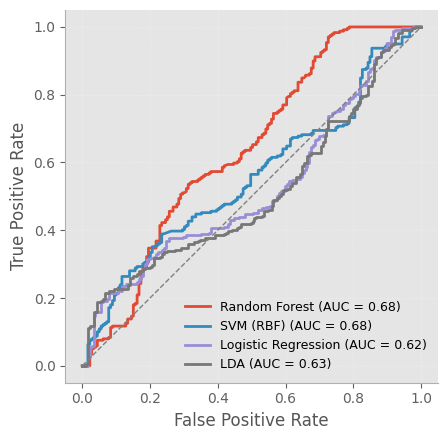

In [ ]:
# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


# ======================================================
# ✅ REPRODUCIBILITY
# ======================================================
np.random.seed(42)
random.seed(42)


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'

data = pd.read_csv(file_path)

# Binary labels
data['label'] = data['label'].map({
    "before_HI": 0,
    "during_HI": 1
})

# Subject ID
data['subject_id'] = data['File_Name'].apply(
    lambda x: str(x).split('_')[0]
)


# ======================================================
# ✅ FEATURE SET (11 FEATURES)
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"
]

X = data[sig_features]
y = data['label']
groups = data['subject_id']


# ======================================================
# ✅ MODELS
# ======================================================
models = {

    # --------------------------------------------------
    # RANDOM FOREST
    # --------------------------------------------------
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),

    # --------------------------------------------------
    # SVM (RBF)
    # --------------------------------------------------
    "SVM (RBF)": SVC(
        kernel='rbf',
        C=10,
        gamma=0.01,
        probability=True,
        class_weight='balanced',
        random_state=42
    ),

    # --------------------------------------------------
    # LOGISTIC REGRESSION
    # --------------------------------------------------
    "Logistic Regression": LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ),

    # --------------------------------------------------
    # LDA
    # --------------------------------------------------
    "LDA": LDA()
}


# ======================================================
# ✅ LOSO CROSS-VALIDATION
# ======================================================
logo = LeaveOneGroupOut()


# ======================================================
# ✅ PLOT (Clean Journal Style)
# ======================================================
fig, ax = plt.subplots(figsize=(5.5, 4.5))

for name, model in models.items():

    fold_aucs = []

    y_true_all = []
    y_prob_all = []

    print("\n========================================")
    print(f"{name} — LOSO Validation")
    print("========================================")

    # ==================================================
    # LOSO LOOP
    # ==================================================
    for fold, (train_idx, test_idx) in enumerate(
            logo.split(X, y, groups), 1):

        # -------------------------------------------------
        # TRAIN / TEST SPLIT
        # -------------------------------------------------
        X_train_raw = X.iloc[train_idx].copy()
        X_test_raw = X.iloc[test_idx].copy()

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # -------------------------------------------------
        # ✅ FOLD-WISE NORMALIZATION
        # -------------------------------------------------
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        # -------------------------------------------------
        # CONVERT BACK TO DATAFRAME
        # -------------------------------------------------
        X_train = pd.DataFrame(
            X_train,
            columns=sig_features
        )

        X_test = pd.DataFrame(
            X_test,
            columns=sig_features
        )

        # -------------------------------------------------
        # ✅ BASELINE-RELATIVE TRANSFORMATION
        # -------------------------------------------------
        baseline_train = X_train[
            y_train.values == 0
        ].mean(axis=0)

        X_train = X_train - baseline_train
        X_test = X_test - baseline_train

        # -------------------------------------------------
        # TRAIN MODEL
        # -------------------------------------------------
        model.fit(X_train, y_train)

        # -------------------------------------------------
        # PREDICT PROBABILITIES
        # -------------------------------------------------
        probs = model.predict_proba(X_test)[:, 1]

        # Skip invalid fold
        if len(np.unique(y_test)) < 2:
            continue

        # -------------------------------------------------
        # FOLD AUC
        # -------------------------------------------------
        fold_auc = roc_auc_score(y_test, probs)

        fold_aucs.append(fold_auc)

        print(f"Subject {fold} AUC: {fold_auc:.4f}")

        # Store predictions
        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # ==================================================
    # FINAL METRICS
    # ==================================================
    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    print(f"\nMean LOSO AUC ± SD: "
          f"{mean_auc:.4f} ± {std_auc:.4f}")

    # --------------------------------------------------
    # ROC CURVE
    # --------------------------------------------------
    fpr, tpr, _ = roc_curve(
        y_true_all,
        y_prob_all
    )

    ax.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{name} (AUC = {mean_auc:.2f})"
    )


# ======================================================
# ✅ DIAGONAL REFERENCE LINE
# ======================================================
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1,
    color='gray'
)


# ======================================================
# ✅ STYLING (Elsevier Clean Look)
# ======================================================
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Light thin axes
ax.spines['left'].set_color('#B0B0B0')
ax.spines['bottom'].set_color('#B0B0B0')

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# Light ticks
ax.tick_params(
    colors='#606060',
    width=0.8
)

# Light thin grid
ax.grid(
    True,
    linestyle='--',
    linewidth=0.4,
    alpha=0.35
)

# Legend without frame
ax.legend(
    frameon=False,
    fontsize=9,
    loc="lower right"
)

# Square ROC appearance
ax.set_aspect(
    'equal',
    adjustable='box'
)

plt.tight_layout()
plt.show()

In [ ]:
# ======================================================
# ✅ DIAGONAL REFERENCE LINE
# ======================================================
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1,
    color='gray'
)


# ======================================================
# ✅ STYLING (Elsevier Clean Look)
# ======================================================
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

# ------------------------------------------------------
# REMOVE TOP / RIGHT SPINES
# ------------------------------------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ------------------------------------------------------
# LIGHT THIN AXES
# ------------------------------------------------------
ax.spines['left'].set_color('#B0B0B0')
ax.spines['bottom'].set_color('#B0B0B0')

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# ------------------------------------------------------
# LIGHT TICKS
# ------------------------------------------------------
ax.tick_params(
    colors='#606060',
    width=0.8
)

# ------------------------------------------------------
# LIGHT THIN GRID
# ------------------------------------------------------
ax.grid(
    True,
    linestyle='--',
    linewidth=0.4,
    alpha=0.35
)

# ------------------------------------------------------
# LEGEND WITHOUT FRAME
# ------------------------------------------------------
ax.legend(
    frameon=False,
    fontsize=9,
    loc="lower right"
)

# ------------------------------------------------------
# SQUARE ROC LOOK
# ------------------------------------------------------
ax.set_aspect(
    'equal',
    adjustable='box'
)

# ------------------------------------------------------
# TIGHT LAYOUT
# ------------------------------------------------------
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>


Random Forest — LOSO Validation
Subject 1 AUC: 0.8956
Subject 2 AUC: 0.9374
Subject 3 AUC: 0.5525
Subject 4 AUC: 0.8111
Subject 5 AUC: 0.2240
Subject 6 AUC: 0.6399

Mean LOSO AUC ± SD: 0.6768 ± 0.2434

SVM (RBF) — LOSO Validation
Subject 1 AUC: 0.7089
Subject 2 AUC: 0.6259
Subject 3 AUC: 0.5740
Subject 4 AUC: 0.9267
Subject 5 AUC: 0.5108
Subject 6 AUC: 0.7257

Mean LOSO AUC ± SD: 0.6787 ± 0.1333

Logistic Regression — LOSO Validation
Subject 1 AUC: 0.5833
Subject 2 AUC: 0.4874
Subject 3 AUC: 0.6011
Subject 4 AUC: 0.9267
Subject 5 AUC: 0.3265
Subject 6 AUC: 0.7867

Mean LOSO AUC ± SD: 0.6186 ± 0.1946

LDA — LOSO Validation
Subject 1 AUC: 0.7122
Subject 2 AUC: 0.5121
Subject 3 AUC: 0.5418
Subject 4 AUC: 0.9089
Subject 5 AUC: 0.2971
Subject 6 AUC: 0.7851

Mean LOSO AUC ± SD: 0.6262 ± 0.2004


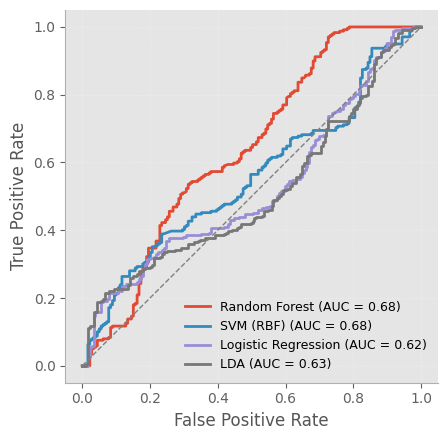

In [ ]:
# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


# ======================================================
# ✅ REPRODUCIBILITY
# ======================================================
np.random.seed(42)
random.seed(42)


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'

data = pd.read_csv(file_path)

# ------------------------------------------------------
# LABEL ENCODING
# ------------------------------------------------------
data['label'] = data['label'].map({
    "before_HI": 0,
    "during_HI": 1
})

# ------------------------------------------------------
# SUBJECT ID
# ------------------------------------------------------
data['subject_id'] = data['File_Name'].apply(
    lambda x: str(x).split('_')[0]
)


# ======================================================
# ✅ FEATURE SET
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"
]

X = data[sig_features]
y = data['label']
groups = data['subject_id']


# ======================================================
# ✅ MODELS
# ======================================================
models = {

    # --------------------------------------------------
    # RANDOM FOREST
    # --------------------------------------------------
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),

    # --------------------------------------------------
    # SVM (RBF)
    # --------------------------------------------------
    "SVM (RBF)": SVC(
        kernel='rbf',
        C=10,
        gamma=0.01,
        probability=True,
        class_weight='balanced',
        random_state=42
    ),

    # --------------------------------------------------
    # LOGISTIC REGRESSION
    # --------------------------------------------------
    "Logistic Regression": LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ),

    # --------------------------------------------------
    # LDA
    # --------------------------------------------------
    "LDA": LDA()
}


# ======================================================
# ✅ LOSO CROSS-VALIDATION
# ======================================================
logo = LeaveOneGroupOut()


# ======================================================
# ✅ PLOT (Clean Journal Style)
# ======================================================
fig, ax = plt.subplots(figsize=(5.5, 4.5))

for name, model in models.items():

    fold_aucs = []

    y_true_all = []
    y_prob_all = []

    print("\n========================================")
    print(f"{name} — LOSO Validation")
    print("========================================")

    # ==================================================
    # LOSO LOOP
    # ==================================================
    for fold, (train_idx, test_idx) in enumerate(
            logo.split(X, y, groups), 1):

        # -------------------------------------------------
        # TRAIN / TEST SPLIT
        # -------------------------------------------------
        X_train_raw = X.iloc[train_idx].copy()
        X_test_raw = X.iloc[test_idx].copy()

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # -------------------------------------------------
        # ✅ FOLD-WISE NORMALIZATION
        # -------------------------------------------------
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        # -------------------------------------------------
        # CONVERT TO DATAFRAME
        # -------------------------------------------------
        X_train = pd.DataFrame(
            X_train,
            columns=sig_features
        )

        X_test = pd.DataFrame(
            X_test,
            columns=sig_features
        )

        # -------------------------------------------------
        # ✅ BASELINE-RELATIVE TRANSFORMATION
        # -------------------------------------------------
        baseline_train = X_train[
            y_train.values == 0
        ].mean(axis=0)

        X_train = X_train - baseline_train
        X_test = X_test - baseline_train

        # -------------------------------------------------
        # TRAIN MODEL
        # -------------------------------------------------
        model.fit(X_train, y_train)

        # -------------------------------------------------
        # PREDICT PROBABILITIES
        # -------------------------------------------------
        probs = model.predict_proba(X_test)[:, 1]

        # -------------------------------------------------
        # SKIP INVALID FOLD
        # -------------------------------------------------
        if len(np.unique(y_test)) < 2:
            continue

        # -------------------------------------------------
        # FOLD AUC
        # -------------------------------------------------
        fold_auc = roc_auc_score(y_test, probs)

        fold_aucs.append(fold_auc)

        print(f"Subject {fold} AUC: {fold_auc:.4f}")

        # -------------------------------------------------
        # STORE PREDICTIONS
        # -------------------------------------------------
        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # ==================================================
    # FINAL METRICS
    # ==================================================
    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    print(
        f"\nMean LOSO AUC ± SD: "
        f"{mean_auc:.4f} ± {std_auc:.4f}"
    )

    # --------------------------------------------------
    # ROC CURVE
    # --------------------------------------------------
    fpr, tpr, _ = roc_curve(
        y_true_all,
        y_prob_all
    )

    ax.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{name} (AUC = {mean_auc:.2f})"
    )


# ======================================================
# ✅ DIAGONAL REFERENCE LINE
# ======================================================
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1,
    color='gray'
)


# ======================================================
# ✅ STYLING (Elsevier Clean Look)
# ======================================================
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

# ------------------------------------------------------
# REMOVE TOP / RIGHT SPINES
# ------------------------------------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ------------------------------------------------------
# LIGHT THIN AXES
# ------------------------------------------------------
ax.spines['left'].set_color('#B0B0B0')
ax.spines['bottom'].set_color('#B0B0B0')

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# ------------------------------------------------------
# LIGHT TICKS
# ------------------------------------------------------
ax.tick_params(
    colors='#606060',
    width=0.8
)

# ------------------------------------------------------
# LIGHT THIN GRID
# ------------------------------------------------------
ax.grid(
    True,
    linestyle='--',
    linewidth=0.4,
    alpha=0.35
)

# ------------------------------------------------------
# LEGEND WITHOUT FRAME
# ------------------------------------------------------
ax.legend(
    frameon=False,
    fontsize=9,
    loc="lower right"
)

# ------------------------------------------------------
# SQUARE ROC LOOK
# ------------------------------------------------------
ax.set_aspect(
    'equal',
    adjustable='box'
)

# ------------------------------------------------------
# TIGHT LAYOUT
# ------------------------------------------------------
plt.tight_layout()

# ------------------------------------------------------
# SHOW FIGURE
# ------------------------------------------------------
plt.show()

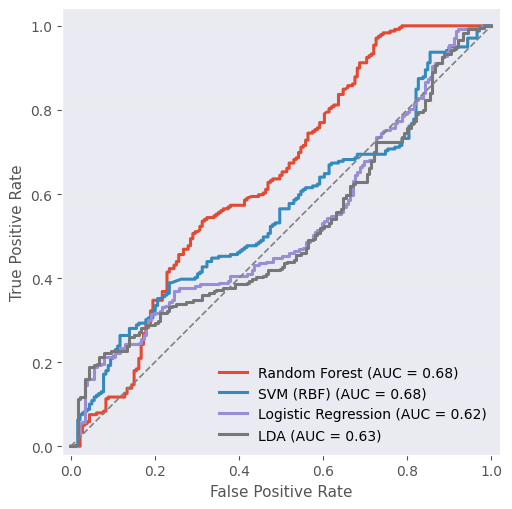

In [ ]:

# ======================================================
# ✅ FIGURE STYLE (MATCH REFERENCE)
# ======================================================
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(5.2, 5.2))

# Lighter background like reference
ax.set_facecolor('#EAEAF2')


# ======================================================
# ✅ LOSO LOOP
# ======================================================
for name, model in models.items():

    fold_aucs = []

    y_true_all = []
    y_prob_all = []

    for fold, (train_idx, test_idx) in enumerate(
            logo.split(X, y, groups), 1):

        # -------------------------------------------------
        # TRAIN / TEST SPLIT
        # -------------------------------------------------
        X_train_raw = X.iloc[train_idx].copy()
        X_test_raw = X.iloc[test_idx].copy()

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # -------------------------------------------------
        # FOLD-WISE NORMALIZATION
        # -------------------------------------------------
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        # -------------------------------------------------
        # CONVERT BACK TO DATAFRAME
        # -------------------------------------------------
        X_train = pd.DataFrame(
            X_train,
            columns=sig_features
        )

        X_test = pd.DataFrame(
            X_test,
            columns=sig_features
        )

        # -------------------------------------------------
        # BASELINE RELATIVE TRANSFORMATION
        # -------------------------------------------------
        baseline_train = X_train[
            y_train.values == 0
        ].mean(axis=0)

        X_train = X_train - baseline_train
        X_test = X_test - baseline_train

        # -------------------------------------------------
        # TRAIN
        # -------------------------------------------------
        model.fit(X_train, y_train)

        # -------------------------------------------------
        # PREDICT
        # -------------------------------------------------
        probs = model.predict_proba(X_test)[:, 1]

        if len(np.unique(y_test)) < 2:
            continue

        # -------------------------------------------------
        # AUC
        # -------------------------------------------------
        fold_auc = roc_auc_score(y_test, probs)

        fold_aucs.append(fold_auc)

        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # ==================================================
    # FINAL ROC
    # ==================================================
    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    mean_auc = np.mean(fold_aucs)

    fpr, tpr, _ = roc_curve(
        y_true_all,
        y_prob_all
    )

    # --------------------------------------------------
    # ROC CURVE
    # --------------------------------------------------
    ax.plot(
        fpr,
        tpr,
        lw=2.2,
        label=f"{name} (AUC = {mean_auc:.2f})"
    )


# ======================================================
# ✅ DIAGONAL LINE
# ======================================================
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1.2,
    color='gray'
)


# ======================================================
# ✅ AXES LABELS
# ======================================================
ax.set_xlabel(
    "False Positive Rate",
    fontsize=11
)

ax.set_ylabel(
    "True Positive Rate",
    fontsize=11
)


# ======================================================
# ✅ LIMITS
# ======================================================
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.04])


# ======================================================
# ✅ LIGHT GRID
# ======================================================
ax.grid(
    True,
    linestyle='--',
    linewidth=0.4,
    alpha=0.25
)


# ======================================================
# ✅ REMOVE TOP/RIGHT SPINES
# ======================================================
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ======================================================
# ✅ LEGEND (MATCH REFERENCE)
# ======================================================
ax.legend(
    frameon=False,
    fontsize=10,
    loc='lower right'
)


# ======================================================
# ✅ SQUARE LOOK
# ======================================================
ax.set_aspect(
    'equal',
    adjustable='box'
)


# ======================================================
# ✅ FINAL LAYOUT
# ======================================================
plt.tight_layout()

plt.show()

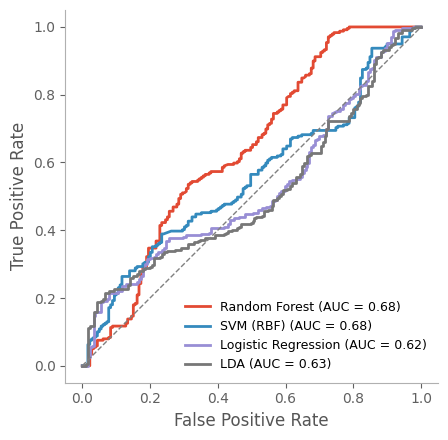

In [ ]:

# ======================================================
# ✅ FIGURE
# ======================================================
fig, ax = plt.subplots(figsize=(5.5, 4.5))

# ------------------------------------------------------
# WHITE BACKGROUND
# ------------------------------------------------------
fig.patch.set_facecolor('white')
ax.set_facecolor('white')


# ======================================================
# ✅ ROC CURVES
# ======================================================
for name, model in models.items():

    fold_aucs = []

    y_true_all = []
    y_prob_all = []

    for fold, (train_idx, test_idx) in enumerate(
            logo.split(X, y, groups), 1):

        # -------------------------------------------------
        # TRAIN / TEST SPLIT
        # -------------------------------------------------
        X_train_raw = X.iloc[train_idx].copy()
        X_test_raw = X.iloc[test_idx].copy()

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # -------------------------------------------------
        # FOLD-WISE NORMALIZATION
        # -------------------------------------------------
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        # -------------------------------------------------
        # CONVERT TO DATAFRAME
        # -------------------------------------------------
        X_train = pd.DataFrame(
            X_train,
            columns=sig_features
        )

        X_test = pd.DataFrame(
            X_test,
            columns=sig_features
        )

        # -------------------------------------------------
        # BASELINE RELATIVE TRANSFORMATION
        # -------------------------------------------------
        baseline_train = X_train[
            y_train.values == 0
        ].mean(axis=0)

        X_train = X_train - baseline_train
        X_test = X_test - baseline_train

        # -------------------------------------------------
        # TRAIN MODEL
        # -------------------------------------------------
        model.fit(X_train, y_train)

        # -------------------------------------------------
        # PREDICT
        # -------------------------------------------------
        probs = model.predict_proba(X_test)[:, 1]

        if len(np.unique(y_test)) < 2:
            continue

        # -------------------------------------------------
        # AUC
        # -------------------------------------------------
        fold_auc = roc_auc_score(y_test, probs)

        fold_aucs.append(fold_auc)

        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # ==================================================
    # FINAL ROC
    # ==================================================
    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    mean_auc = np.mean(fold_aucs)

    fpr, tpr, _ = roc_curve(
        y_true_all,
        y_prob_all
    )

    ax.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{name} (AUC = {mean_auc:.2f})"
    )


# ======================================================
# ✅ DIAGONAL REFERENCE LINE
# ======================================================
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1,
    color='gray'
)


# ======================================================
# ✅ AXIS LABELS
# ======================================================
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")


# ======================================================
# ✅ REMOVE TOP / RIGHT SPINES
# ======================================================
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ======================================================
# ✅ LIGHT SPINES
# ======================================================
ax.spines['left'].set_color('#B0B0B0')
ax.spines['bottom'].set_color('#B0B0B0')

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)


# ======================================================
# ✅ LIGHT TICKS
# ======================================================
ax.tick_params(
    colors='#606060',
    width=0.8
)


# ======================================================
# ✅ VERY LIGHT GRID
# ======================================================
ax.grid(
    True,
    linestyle='--',
    linewidth=0.35,
    alpha=0.18
)


# ======================================================
# ✅ LEGEND
# ======================================================
ax.legend(
    frameon=False,
    fontsize=9,
    loc="lower right"
)


# ======================================================
# ✅ SQUARE ROC LOOK
# ======================================================
ax.set_aspect(
    'equal',
    adjustable='box'
)


# ======================================================
# ✅ TIGHT LAYOUT
# ======================================================
plt.tight_layout()

plt.show()


Random Forest — LOSO Validation
Subject 1 AUC: 0.8956
Subject 2 AUC: 0.9374
Subject 3 AUC: 0.5525
Subject 4 AUC: 0.8111
Subject 5 AUC: 0.2240
Subject 6 AUC: 0.6399

Mean LOSO AUC ± SD: 0.6768 ± 0.2434

SVM (RBF) — LOSO Validation
Subject 1 AUC: 0.7089
Subject 2 AUC: 0.6259
Subject 3 AUC: 0.5740
Subject 4 AUC: 0.9267
Subject 5 AUC: 0.5108
Subject 6 AUC: 0.7257

Mean LOSO AUC ± SD: 0.6787 ± 0.1333

Logistic Regression — LOSO Validation
Subject 1 AUC: 0.5833
Subject 2 AUC: 0.4874
Subject 3 AUC: 0.6011
Subject 4 AUC: 0.9267
Subject 5 AUC: 0.3265
Subject 6 AUC: 0.7867

Mean LOSO AUC ± SD: 0.6186 ± 0.1946

LDA — LOSO Validation
Subject 1 AUC: 0.7122
Subject 2 AUC: 0.5121
Subject 3 AUC: 0.5418
Subject 4 AUC: 0.9089
Subject 5 AUC: 0.2971
Subject 6 AUC: 0.7851

Mean LOSO AUC ± SD: 0.6262 ± 0.2004


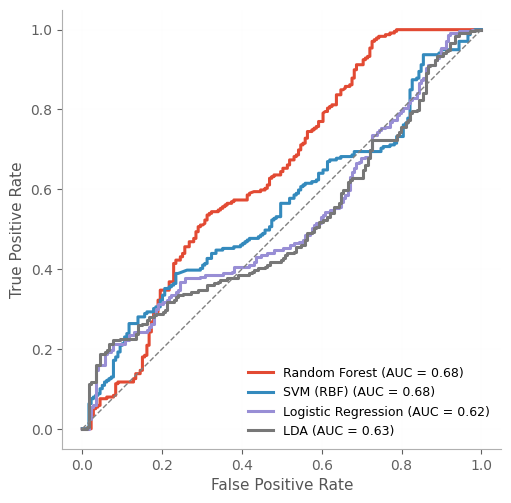

In [ ]:
# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


# ======================================================
# ✅ REPRODUCIBILITY
# ======================================================
np.random.seed(42)
random.seed(42)


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'

data = pd.read_csv(file_path)

# ------------------------------------------------------
# LABEL ENCODING
# ------------------------------------------------------
data['label'] = data['label'].map({
    "before_HI": 0,
    "during_HI": 1
})

# ------------------------------------------------------
# SUBJECT ID
# ------------------------------------------------------
data['subject_id'] = data['File_Name'].apply(
    lambda x: str(x).split('_')[0]
)


# ======================================================
# ✅ FEATURE SET
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"
]

X = data[sig_features]
y = data['label']
groups = data['subject_id']


# ======================================================
# ✅ MODELS
# ======================================================
models = {

    # --------------------------------------------------
    # RANDOM FOREST
    # --------------------------------------------------
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),

    # --------------------------------------------------
    # SVM (RBF)
    # --------------------------------------------------
    "SVM (RBF)": SVC(
        kernel='rbf',
        C=10,
        gamma=0.01,
        probability=True,
        class_weight='balanced',
        random_state=42
    ),

    # --------------------------------------------------
    # LOGISTIC REGRESSION
    # --------------------------------------------------
    "Logistic Regression": LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ),

    # --------------------------------------------------
    # LDA
    # --------------------------------------------------
    "LDA": LDA()
}


# ======================================================
# ✅ LOSO CROSS-VALIDATION
# ======================================================
logo = LeaveOneGroupOut()


# ======================================================
# ✅ FIGURE
# ======================================================
fig, ax = plt.subplots(figsize=(5.2, 5.2))

# ------------------------------------------------------
# WHITE BACKGROUND
# ------------------------------------------------------
fig.patch.set_facecolor('white')
ax.set_facecolor('white')


# ======================================================
# ✅ ROC CURVES
# ======================================================
for name, model in models.items():

    fold_aucs = []

    y_true_all = []
    y_prob_all = []

    print("\n========================================")
    print(f"{name} — LOSO Validation")
    print("========================================")

    # ==================================================
    # LOSO LOOP
    # ==================================================
    for fold, (train_idx, test_idx) in enumerate(
            logo.split(X, y, groups), 1):

        # -------------------------------------------------
        # TRAIN / TEST SPLIT
        # -------------------------------------------------
        X_train_raw = X.iloc[train_idx].copy()
        X_test_raw = X.iloc[test_idx].copy()

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # -------------------------------------------------
        # ✅ FOLD-WISE NORMALIZATION
        # -------------------------------------------------
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        # -------------------------------------------------
        # CONVERT TO DATAFRAME
        # -------------------------------------------------
        X_train = pd.DataFrame(
            X_train,
            columns=sig_features
        )

        X_test = pd.DataFrame(
            X_test,
            columns=sig_features
        )

        # -------------------------------------------------
        # ✅ BASELINE-RELATIVE TRANSFORMATION
        # -------------------------------------------------
        baseline_train = X_train[
            y_train.values == 0
        ].mean(axis=0)

        X_train = X_train - baseline_train
        X_test = X_test - baseline_train

        # -------------------------------------------------
        # TRAIN MODEL
        # -------------------------------------------------
        model.fit(X_train, y_train)

        # -------------------------------------------------
        # PREDICT PROBABILITIES
        # -------------------------------------------------
        probs = model.predict_proba(X_test)[:, 1]

        # -------------------------------------------------
        # SKIP INVALID FOLD
        # -------------------------------------------------
        if len(np.unique(y_test)) < 2:
            continue

        # -------------------------------------------------
        # FOLD AUC
        # -------------------------------------------------
        fold_auc = roc_auc_score(y_test, probs)

        fold_aucs.append(fold_auc)

        print(f"Subject {fold} AUC: {fold_auc:.4f}")

        # -------------------------------------------------
        # STORE PREDICTIONS
        # -------------------------------------------------
        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # ==================================================
    # FINAL METRICS
    # ==================================================
    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    print(
        f"\nMean LOSO AUC ± SD: "
        f"{mean_auc:.4f} ± {std_auc:.4f}"
    )

    # --------------------------------------------------
    # ROC CURVE
    # --------------------------------------------------
    fpr, tpr, _ = roc_curve(
        y_true_all,
        y_prob_all
    )

    ax.plot(
        fpr,
        tpr,
        lw=2.2,
        label=f"{name} (AUC = {mean_auc:.2f})"
    )


# ======================================================
# ✅ DIAGONAL REFERENCE LINE
# ======================================================
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1,
    color='gray'
)


# ======================================================
# ✅ AXIS LABELS
# ======================================================
ax.set_xlabel(
    "False Positive Rate",
    fontsize=11
)

ax.set_ylabel(
    "True Positive Rate",
    fontsize=11
)


# ======================================================
# ✅ REMOVE TOP / RIGHT SPINES
# ======================================================
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ======================================================
# ✅ LIGHT THIN AXES
# ======================================================
ax.spines['left'].set_color('#B0B0B0')
ax.spines['bottom'].set_color('#B0B0B0')

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)


# ======================================================
# ✅ LIGHT TICKS
# ======================================================
ax.tick_params(
    colors='#606060',
    width=0.8
)


# ======================================================
# ✅ VERY LIGHT GRID
# ======================================================
ax.grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.10,
    color='#D8D8D8'
)


# ======================================================
# ✅ LEGEND
# ======================================================
ax.legend(
    frameon=False,
    fontsize=9,
    loc="lower right"
)


# ======================================================
# ✅ SQUARE ROC LOOK
# ======================================================
ax.set_aspect(
    'equal',
    adjustable='box'
)


# ======================================================
# ✅ TIGHT LAYOUT
# ======================================================
plt.tight_layout()

plt.show()

FIGURES


Random Forest — 5-Fold Cross-Validation
Fold 1 AUC: 0.9899
Fold 2 AUC: 0.9638
Fold 3 AUC: 0.9832
Fold 4 AUC: 0.9423
Fold 5 AUC: 0.9885

Mean AUC ± SD: 0.9735 ± 0.0182

SVM (RBF) — 5-Fold Cross-Validation
Fold 1 AUC: 0.9010
Fold 2 AUC: 0.8987
Fold 3 AUC: 0.8837
Fold 4 AUC: 0.8048
Fold 5 AUC: 0.8741

Mean AUC ± SD: 0.8725 ± 0.0353

Logistic Regression — 5-Fold Cross-Validation
Fold 1 AUC: 0.8547
Fold 2 AUC: 0.7598
Fold 3 AUC: 0.8646
Fold 4 AUC: 0.7333
Fold 5 AUC: 0.7902

Mean AUC ± SD: 0.8005 ± 0.0516

LDA — 5-Fold Cross-Validation
Fold 1 AUC: 0.8605
Fold 2 AUC: 0.7656
Fold 3 AUC: 0.8756
Fold 4 AUC: 0.7202
Fold 5 AUC: 0.7665

Mean AUC ± SD: 0.7977 ± 0.0600


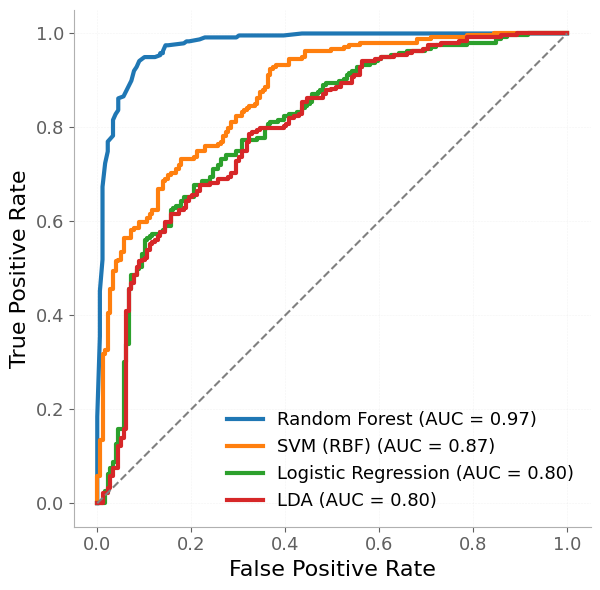

In [ ]:
# ======================================================
# ✅ FIGURE 8(a)
# SEGMENT-WISE ROC ANALYSIS
# PUBLICATION-QUALITY VERSION
# ======================================================

# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'

data = pd.read_csv(file_path)

X = data.drop(
    columns=[
        'Sl. No:',
        'Segment_Number',
        'File_Name',
        'label'
    ]
)

y = data['label'].map({
    "before_HI": 0,
    "during_HI": 1
})


# ======================================================
# ✅ FINAL FEATURE SET
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"
]

X_final = X[sig_features]


# ======================================================
# ✅ 5-FOLD STRATIFIED CROSS-VALIDATION
# ======================================================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=3
)

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        random_state=3
    ),

    "SVM (RBF)": SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=3
    ),

    "Logistic Regression": LogisticRegression(
        C=1.0,
        solver='liblinear',
        penalty='l2',
        random_state=3
    ),

    "LDA": LDA()
}


# ======================================================
# ✅ PUBLICATION-QUALITY FIGURE
# ======================================================
fig, ax = plt.subplots(figsize=(7, 6))

# White background
fig.patch.set_facecolor('white')
ax.set_facecolor('white')


# ======================================================
# ✅ ROC CURVES
# ======================================================
for name, model in models.items():

    fold_aucs = []

    y_true_all = []
    y_prob_all = []

    print("\n========================================")
    print(f"{name} — 5-Fold Cross-Validation")
    print("========================================")

    for fold, (train_idx, test_idx) in enumerate(
            skf.split(X_final, y), 1):

        X_train = X_final.iloc[train_idx]
        X_test = X_final.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # -------------------------------------------------
        # SCALING
        # -------------------------------------------------
        if name in [
            "SVM (RBF)",
            "Logistic Regression",
            "LDA"
        ]:

            scaler = StandardScaler()

            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # -------------------------------------------------
        # TRAIN
        # -------------------------------------------------
        model.fit(X_train, y_train)

        # -------------------------------------------------
        # PREDICT
        # -------------------------------------------------
        probs = model.predict_proba(X_test)[:, 1]

        # -------------------------------------------------
        # AUC
        # -------------------------------------------------
        fold_auc = roc_auc_score(y_test, probs)

        fold_aucs.append(fold_auc)

        print(f"Fold {fold} AUC: {fold_auc:.4f}")

        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # ==================================================
    # FINAL METRICS
    # ==================================================
    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    print(
        f"\nMean AUC ± SD: "
        f"{mean_auc:.4f} ± {std_auc:.4f}"
    )

    # --------------------------------------------------
    # ROC CURVE
    # --------------------------------------------------
    fpr, tpr, _ = roc_curve(
        y_true_all,
        y_prob_all
    )

    ax.plot(
        fpr,
        tpr,
        lw=3,
        label=f"{name} (AUC = {mean_auc:.2f})"
    )


# ======================================================
# ✅ DIAGONAL REFERENCE LINE
# ======================================================
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1.5,
    color='gray'
)


# ======================================================
# ✅ AXIS LABELS
# ======================================================
ax.set_xlabel(
    "False Positive Rate",
    fontsize=16
)

ax.set_ylabel(
    "True Positive Rate",
    fontsize=16
)


# ======================================================
# ✅ LIGHT SPINES
# ======================================================
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#B0B0B0')
ax.spines['bottom'].set_color('#B0B0B0')

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)


# ======================================================
# ✅ TICKS
# ======================================================
ax.tick_params(
    colors='#606060',
    width=0.8,
    labelsize=13
)


# ======================================================
# ✅ LIGHT GRID
# ======================================================
ax.grid(
    True,
    linestyle='--',
    linewidth=0.4,
    alpha=0.15
)


# ======================================================
# ✅ LEGEND
# ======================================================
ax.legend(
    frameon=False,
    fontsize=13,
    loc="lower right"
)


# ======================================================
# ✅ SQUARE ROC LOOK
# ======================================================
ax.set_aspect(
    'equal',
    adjustable='box'
)


# ======================================================
# ✅ SAVE HIGH-QUALITY FIGURE
# ======================================================
plt.tight_layout()

plt.savefig(
    "ROC_AUC_curve_segmentwise.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()


Random Forest — LOSO Validation
Subject 1 AUC: 0.8956
Subject 2 AUC: 0.9374
Subject 3 AUC: 0.5525
Subject 4 AUC: 0.8111
Subject 5 AUC: 0.2240
Subject 6 AUC: 0.6399

Mean LOSO AUC ± SD: 0.6768 ± 0.2434

SVM (RBF) — LOSO Validation
Subject 1 AUC: 0.7089
Subject 2 AUC: 0.6259
Subject 3 AUC: 0.5740
Subject 4 AUC: 0.9267
Subject 5 AUC: 0.5108
Subject 6 AUC: 0.7257

Mean LOSO AUC ± SD: 0.6787 ± 0.1333

Logistic Regression — LOSO Validation
Subject 1 AUC: 0.5833
Subject 2 AUC: 0.4874
Subject 3 AUC: 0.6011
Subject 4 AUC: 0.9267
Subject 5 AUC: 0.3265
Subject 6 AUC: 0.7867

Mean LOSO AUC ± SD: 0.6186 ± 0.1946

LDA — LOSO Validation
Subject 1 AUC: 0.7122
Subject 2 AUC: 0.5121
Subject 3 AUC: 0.5418
Subject 4 AUC: 0.9089
Subject 5 AUC: 0.2971
Subject 6 AUC: 0.7851

Mean LOSO AUC ± SD: 0.6262 ± 0.2004


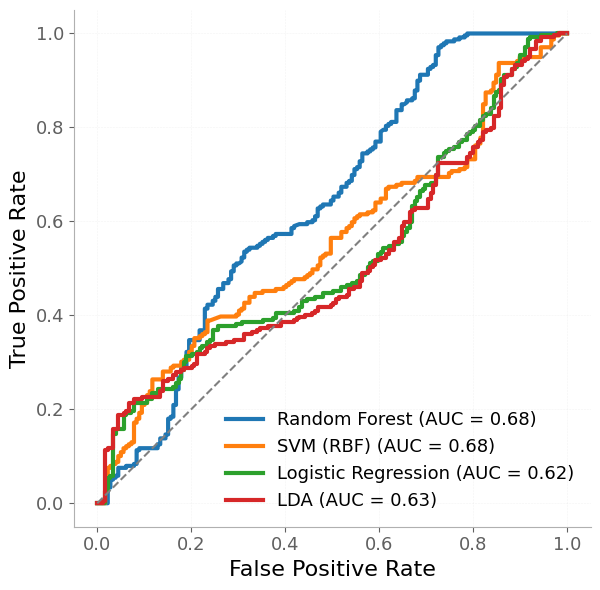

In [ ]:
# ======================================================
# ✅ FIGURE 8(b)
# SUBJECT-WISE LOSO ROC ANALYSIS
# PUBLICATION-QUALITY VERSION
# ======================================================

# ======================================================
# ✅ IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


# ======================================================
# ✅ REPRODUCIBILITY
# ======================================================
np.random.seed(42)
random.seed(42)


# ======================================================
# ✅ LOAD DATA
# ======================================================
file_path = '/content/drive/MyDrive/Features_CS6/2min_35_Combined_Features.csv'

data = pd.read_csv(file_path)

# ------------------------------------------------------
# LABEL ENCODING
# ------------------------------------------------------
data['label'] = data['label'].map({
    "before_HI": 0,
    "during_HI": 1
})

# ------------------------------------------------------
# SUBJECT ID
# ------------------------------------------------------
data['subject_id'] = data['File_Name'].apply(
    lambda x: str(x).split('_')[0]
)


# ======================================================
# ✅ FEATURE SET
# ======================================================
sig_features = [
    "approximateEntropy",
    "sampleEntropy",
    "fd_bandPower",
    "renyiEntropy",
    "lempelZivComplexity",
    "singularValueDecompositionEntropy",
    "minimum",
    "numberOfZeroCrossing",
    "fd_median",
    "petrosianFd",
    "katzFd"
]

X = data[sig_features]
y = data['label']
groups = data['subject_id']


# ======================================================
# ✅ MODELS
# ======================================================
models = {

    # --------------------------------------------------
    # RANDOM FOREST
    # --------------------------------------------------
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),

    # --------------------------------------------------
    # SVM (RBF)
    # --------------------------------------------------
    "SVM (RBF)": SVC(
        kernel='rbf',
        C=10,
        gamma=0.01,
        probability=True,
        class_weight='balanced',
        random_state=42
    ),

    # --------------------------------------------------
    # LOGISTIC REGRESSION
    # --------------------------------------------------
    "Logistic Regression": LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ),

    # --------------------------------------------------
    # LDA
    # --------------------------------------------------
    "LDA": LDA()
}


# ======================================================
# ✅ LOSO CROSS-VALIDATION
# ======================================================
logo = LeaveOneGroupOut()


# ======================================================
# ✅ PUBLICATION-QUALITY FIGURE
# ======================================================
fig, ax = plt.subplots(figsize=(7, 6))

# ------------------------------------------------------
# WHITE BACKGROUND
# ------------------------------------------------------
fig.patch.set_facecolor('white')
ax.set_facecolor('white')


# ======================================================
# ✅ ROC CURVES
# ======================================================
for name, model in models.items():

    fold_aucs = []

    y_true_all = []
    y_prob_all = []

    print("\n========================================")
    print(f"{name} — LOSO Validation")
    print("========================================")

    # ==================================================
    # LOSO LOOP
    # ==================================================
    for fold, (train_idx, test_idx) in enumerate(
            logo.split(X, y, groups), 1):

        # -------------------------------------------------
        # TRAIN / TEST SPLIT
        # -------------------------------------------------
        X_train_raw = X.iloc[train_idx].copy()
        X_test_raw = X.iloc[test_idx].copy()

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # -------------------------------------------------
        # ✅ FOLD-WISE NORMALIZATION
        # -------------------------------------------------
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        # -------------------------------------------------
        # CONVERT TO DATAFRAME
        # -------------------------------------------------
        X_train = pd.DataFrame(
            X_train,
            columns=sig_features
        )

        X_test = pd.DataFrame(
            X_test,
            columns=sig_features
        )

        # -------------------------------------------------
        # ✅ BASELINE-RELATIVE TRANSFORMATION
        # -------------------------------------------------
        baseline_train = X_train[
            y_train.values == 0
        ].mean(axis=0)

        X_train = X_train - baseline_train
        X_test = X_test - baseline_train

        # -------------------------------------------------
        # TRAIN MODEL
        # -------------------------------------------------
        model.fit(X_train, y_train)

        # -------------------------------------------------
        # PREDICT PROBABILITIES
        # -------------------------------------------------
        probs = model.predict_proba(X_test)[:, 1]

        # -------------------------------------------------
        # SKIP INVALID FOLD
        # -------------------------------------------------
        if len(np.unique(y_test)) < 2:
            continue

        # -------------------------------------------------
        # FOLD AUC
        # -------------------------------------------------
        fold_auc = roc_auc_score(y_test, probs)

        fold_aucs.append(fold_auc)

        print(f"Subject {fold} AUC: {fold_auc:.4f}")

        # -------------------------------------------------
        # STORE PREDICTIONS
        # -------------------------------------------------
        y_true_all.extend(y_test)
        y_prob_all.extend(probs)

    # ==================================================
    # FINAL METRICS
    # ==================================================
    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)

    print(
        f"\nMean LOSO AUC ± SD: "
        f"{mean_auc:.4f} ± {std_auc:.4f}"
    )

    # --------------------------------------------------
    # ROC CURVE
    # --------------------------------------------------
    fpr, tpr, _ = roc_curve(
        y_true_all,
        y_prob_all
    )

    ax.plot(
        fpr,
        tpr,
        lw=3,
        label=f"{name} (AUC = {mean_auc:.2f})"
    )


# ======================================================
# ✅ DIAGONAL REFERENCE LINE
# ======================================================
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1.5,
    color='gray'
)


# ======================================================
# ✅ AXIS LABELS
# ======================================================
ax.set_xlabel(
    "False Positive Rate",
    fontsize=16
)

ax.set_ylabel(
    "True Positive Rate",
    fontsize=16
)


# ======================================================
# ✅ LIGHT SPINES
# ======================================================
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#B0B0B0')
ax.spines['bottom'].set_color('#B0B0B0')

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)


# ======================================================
# ✅ TICKS
# ======================================================
ax.tick_params(
    colors='#606060',
    width=0.8,
    labelsize=13
)


# ======================================================
# ✅ LIGHT GRID
# ======================================================
ax.grid(
    True,
    linestyle='--',
    linewidth=0.4,
    alpha=0.15
)


# ======================================================
# ✅ LEGEND
# ======================================================
ax.legend(
    frameon=False,
    fontsize=13,
    loc="lower right"
)


# ======================================================
# ✅ SQUARE ROC LOOK
# ======================================================
ax.set_aspect(
    'equal',
    adjustable='box'
)


# ======================================================
# ✅ SAVE HIGH-QUALITY FIGURE
# ======================================================
plt.tight_layout()

plt.savefig(
    "ROC_AUC_curve_LOSO.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()